# RQ1 Results Analysis: Metrics, Null Distribution, and Significance across All Modality Pairs

This notebook visualises the outputs of one RQ1 benchmark run for the three
modality pairs (`rgb-depth`, `rgb-normals`, `depth-normals`).

What you get below:

1. A summary of the run (config, null state, observed metrics, null draws).
2. A leakage sanity check on the null distribution.
3. **Multi-correction p-value summary** — significance counts under raw,
   BH-FDR and Bonferroni corrections.
4. Per-pair detail plots: observed value vs layer (linear and log scale),
   p-values / adjusted p-values / z-score vs layer, per-layer null
   histograms and null-mean (log) curves.
5. Optional diagnostics: scene-type enrichment in the high-null tail.
6. Per-pair interpretation plots: log fold-change, volcano-style plot and
   z-score / fold-change heatmaps.
7. **Cross-pair comparison plots** — the modality pair becomes the
   comparison dimension (lines, p-values, heatmaps and bar charts).
8. A report-ready CSV table including all three p-value flavours.

Set `RUN_ID` in the setup cell to point at the run you want to inspect.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----
RUN_ID = "rq1_final_hypersim-20260525-000411"
NULL_FILENAME = "null_distribution.csv"
NULL_STATE_FILENAME = "null_distribution_state.json"
ALPHA = 0.01  # significance threshold for p-value plots

# ---- Resolve project root ----
cwd = Path.cwd().resolve()
if (cwd / "README.md").exists():
    project_root = cwd
elif (cwd.parent / "README.md").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError("Could not find project root (README.md not found).")

run_dir = project_root / "results" / "runs" / RUN_ID
null_dir = project_root / "results" / "runs" / "null_distributions" / RUN_ID

metrics_path = run_dir / "metrics" / "metrics.csv"
null_path = null_dir / NULL_FILENAME
null_state_path = null_dir / NULL_STATE_FILENAME

# ---- Load ----
metrics = pd.read_csv(metrics_path)
null_df = pd.read_csv(null_path)
null_state = (
    json.loads(null_state_path.read_text(encoding="utf-8"))
    if null_state_path.exists()
    else {}
)


def _layer_idx(s):
    """Extract a numeric index from a layer name like 'layer_07'."""
    try:
        return int(str(s).split("_")[-1])
    except Exception:
        return 10**9


metrics["layer_idx"] = metrics["layer"].map(_layer_idx)
metrics = metrics.sort_values(["pair", "metric", "layer_idx"]).reset_index(drop=True)
null_df["layer_idx"] = null_df["layer"].map(_layer_idx)
null_df = null_df.sort_values(["pair", "metric", "layer_idx", "draw_id"]).reset_index(drop=True)

# ---- Bonferroni correction (global family across all hypotheses) ----
# The pipeline only stores BH-FDR in `p_value_adjusted`; we recompute
# Bonferroni here so the notebook can show both side-by-side without
# re-running the benchmark.
N_HYPOTHESES = int(metrics["p_value"].notna().sum())
ALPHA_BONFERRONI = ALPHA / max(N_HYPOTHESES, 1)
metrics["p_value_bonferroni"] = (metrics["p_value"] * N_HYPOTHESES).clip(upper=1.0)
metrics["is_significant_bh_fdr"] = metrics["p_value_adjusted"] <= ALPHA
metrics["is_significant_bonferroni"] = metrics["p_value_bonferroni"] <= ALPHA
metrics["alpha_bonferroni_threshold"] = ALPHA_BONFERRONI

print(f"Run ID            : {RUN_ID}")
print(f"Metrics file      : {metrics_path}")
print(f"Null file         : {null_path}")
print(f"Null state        : {null_state}")
print(f"Hypotheses (N)    : {N_HYPOTHESES}")
print(f"Bonferroni alpha  : {ALPHA_BONFERRONI:.3e} (= {ALPHA} / {N_HYPOTHESES})")
print()
print("Observed metric summary:")
display(
    metrics.groupby(["pair", "metric"])["value"]
    .agg(["count", "min", "mean", "max"])
    .round(4)
)
print("\nNull draws per layer/metric:")
display(
    null_df.groupby(["pair", "metric", "layer"])
    .size()
    .rename("n_draws")
    .reset_index()
)


Run ID            : rq1_final_hypersim-20260525-000411
Metrics file      : C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\rq1_final_hypersim-20260525-000411\metrics\metrics.csv
Null file         : C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\null_distributions\rq1_final_hypersim-20260525-000411\null_distribution.csv
Null state        : {'artifact_path': 'results/runs/null_distributions/rq1_final_hypersim-20260525-000411/null_distribution.csv', 'n_rows': 108000, 'stop_reason': 'adaptive_threshold_reached', 'batches_completed': 5}
Hypotheses (N)    : 108
Bonferroni alpha  : 9.259e-05 (= 0.01 / 108)

Observed metric summary:


count     min    mean     max
pair          metric                                    
depth-normals cka             12  0.1206  0.2788  0.3801
              knn_overlap     12  0.0946  0.2485  0.3166
              pwcca           12  0.2983  0.4286  0.4835
rgb-depth     cka             12  0.0446  0.1346  0.3614
              knn_overlap     12  0.1213  0.3429  0.4935
              pwcca           12  0.2305  0.4308  0.5593
rgb-normals   cka             12  0.0196  0.0747  0.1787
              knn_overlap     12  0.1215  0.2370  0.2999
              pwcca           12  0.2336  0.3747  0.4408


Null draws per layer/metric:


,pair,metric,layer,n_draws
0,depth-normals,cka,layer_00,1000
1,depth-normals,cka,layer_01,1000
2,depth-normals,cka,layer_02,1000
3,depth-normals,cka,layer_03,1000
4,depth-normals,cka,layer_04,1000
...,...,...,...,...
103,rgb-normals,pwcca,layer_07,1000
104,rgb-normals,pwcca,layer_08,1000
105,rgb-normals,pwcca,layer_09,1000
106,rgb-normals,pwcca,layer_10,1000


In [2]:
# Sanity check: no leakage between matched (observed) and null draws.
print("=== Null-distribution leakage check ===\n")

n_total = len(null_df)

# 1) Every null draw must be cross-scene (left != right scene).
if "is_cross_scene" in null_df.columns:
    n_same_scene = int((~null_df["is_cross_scene"]).sum())
    print(f"Same-scene draws   : {n_same_scene} / {n_total}  {'PASS' if n_same_scene == 0 else 'FAIL'}")
elif {"left_scene_id", "right_scene_id"}.issubset(null_df.columns):
    n_same_scene = int((null_df["left_scene_id"] == null_df["right_scene_id"]).sum())
    print(f"Same-scene draws   : {n_same_scene} / {n_total}  {'PASS' if n_same_scene == 0 else 'FAIL'}")
else:
    print("Same-scene check   : SKIP (columns missing)")

# 2) Every null draw should be cross-type (different scene types).
if "is_cross_type" in null_df.columns:
    n_same_type = int((~null_df["is_cross_type"]).sum())
    print(f"Same-type draws    : {n_same_type} / {n_total}  {'PASS' if n_same_type == 0 else 'FAIL'}")
elif {"left_scene_type", "right_scene_type"}.issubset(null_df.columns):
    n_same_type = int((null_df["left_scene_type"] == null_df["right_scene_type"]).sum())
    print(f"Same-type draws    : {n_same_type} / {n_total}  {'PASS' if n_same_type == 0 else 'FAIL'}")
else:
    print("Same-type check    : SKIP (columns missing)")

# 3) No null value should exceed the observed value for its hypothesis.
obs_lookup = metrics.set_index(["pair", "metric", "layer"])["value"].to_dict()
merged_check = null_df.copy()
merged_check["obs_value"] = merged_check.apply(
    lambda r: obs_lookup.get((r["pair"], r["metric"], r["layer"]), np.nan), axis=1
)
n_exceed = int((merged_check["null_value"] >= merged_check["obs_value"]).sum())
pct = 100 * n_exceed / n_total if n_total else 0
print(f"Null >= observed   : {n_exceed} / {n_total} ({pct:.2f}%)  (expect ~0 if signal is strong)")

# 4) Sample-size consistency: all draws for a hypothesis use the same n_samples.
if "n_samples" in null_df.columns:
    sizes = null_df.groupby(["pair", "metric", "layer"])["n_samples"].nunique()
    inconsistent = sizes[sizes > 1]
    if inconsistent.empty:
        print(f"n_samples consistent: PASS (all hypotheses use a single sample size)")
    else:
        print(f"n_samples consistent: FAIL ({len(inconsistent)} hypotheses have mixed sizes)")
        display(inconsistent)

print("\n=== End leakage check ===")

=== Null-distribution leakage check ===

Same-scene draws   : 0 / 108000  PASS
Same-type draws    : 0 / 108000  PASS
Null >= observed   : 0 / 108000 (0.00%)  (expect ~0 if signal is strong)
n_samples consistent: PASS (all hypotheses use a single sample size)

=== End leakage check ===


## Multi-correction p-value summary

The pipeline writes raw p-values (`p_value`) and Benjamini-Hochberg adjusted
p-values (`p_value_adjusted`). For a more conservative read we also compute
the Bonferroni-corrected p-value across the **global family of all
hypotheses** (3 pairs x 12 layers x 3 metrics).

* BH-FDR controls the **false discovery rate** at level alpha — expected
  fraction of false positives among rejections.
* Bonferroni controls the **family-wise error rate** at level alpha —
  probability of any false positive in the whole family. It is the most
  conservative of the three.

A hypothesis is flagged as significant if `p_value_bonferroni <= alpha`,
which is mathematically equivalent to `p_value <= alpha / N_HYPOTHESES`.


In [3]:
# Significance counts per (pair, metric) under each correction.
sig_counts = (
    metrics.assign(
        sig_raw=metrics["p_value"] < ALPHA,
        sig_bh=metrics["is_significant_bh_fdr"],
        sig_bonf=metrics["is_significant_bonferroni"],
    )
    .groupby(["pair", "metric"])[["sig_raw", "sig_bh", "sig_bonf"]]
    .sum()
    .astype(int)
    .rename(columns={
        "sig_raw": "n_sig_raw",
        "sig_bh": "n_sig_bh_fdr",
        "sig_bonf": "n_sig_bonferroni",
    })
)
sig_counts["n_total"] = (
    metrics.groupby(["pair", "metric"])["p_value"].count().astype(int)
)
sig_counts = sig_counts[
    ["n_total", "n_sig_raw", "n_sig_bh_fdr", "n_sig_bonferroni"]
]

print(f"Total hypotheses with a p-value : {N_HYPOTHESES}")
print(f"Significant (raw,    p < {ALPHA}) : {int((metrics['p_value'] < ALPHA).sum())}")
print(f"Significant (BH-FDR, p < {ALPHA}) : {int(metrics['is_significant_bh_fdr'].sum())}")
print(f"Significant (Bonf.,  p < {ALPHA}) : {int(metrics['is_significant_bonferroni'].sum())}")
print()
print("Per (pair, metric) significance counts:")
display(sig_counts)


Total hypotheses with a p-value : 108
Significant (raw,    p < 0.01) : 108
Significant (BH-FDR, p < 0.01) : 108
Significant (Bonf.,  p < 0.01) : 0

Per (pair, metric) significance counts:


n_total  n_sig_raw  n_sig_bh_fdr  n_sig_bonferroni
pair          metric                                                         
depth-normals cka               12         12            12                 0
              knn_overlap       12         12            12                 0
              pwcca             12         12            12                 0
rgb-depth     cka               12         12            12                 0
              knn_overlap       12         12            12                 0
              pwcca             12         12            12                 0
rgb-normals   cka               12         12            12                 0
              knn_overlap       12         12            12                 0
              pwcca             12         12            12                 0

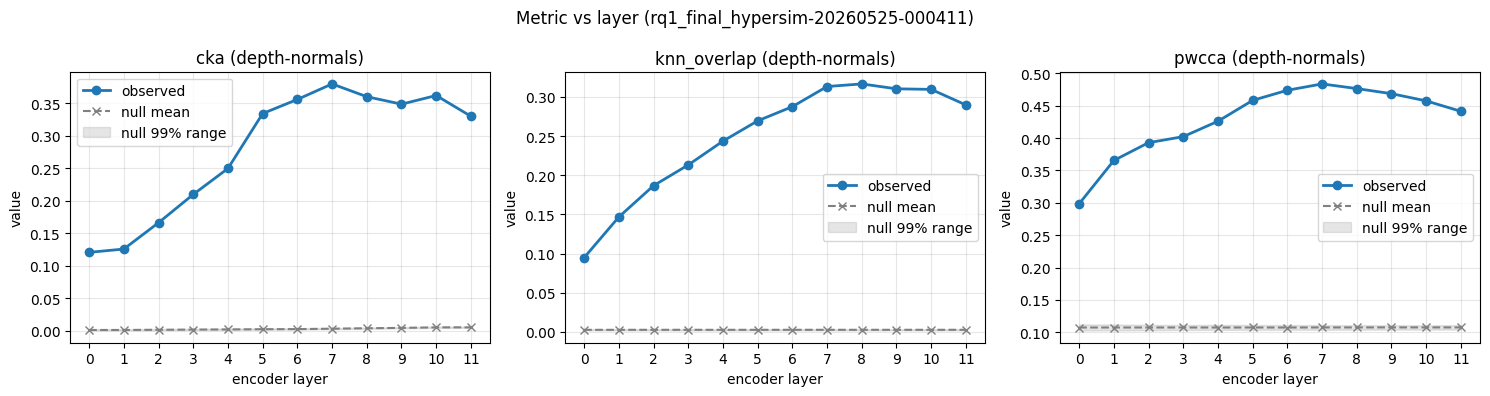

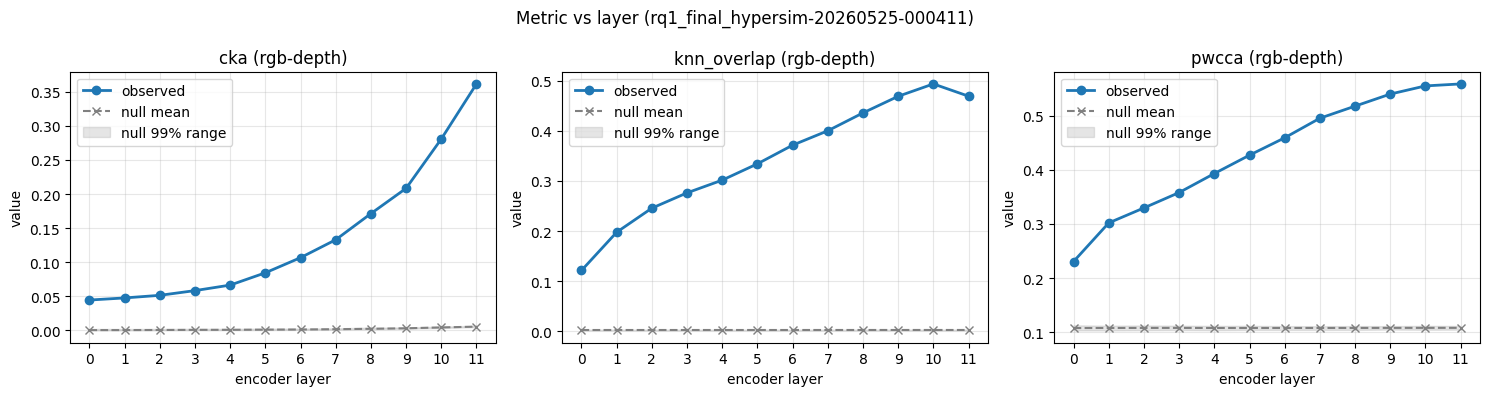

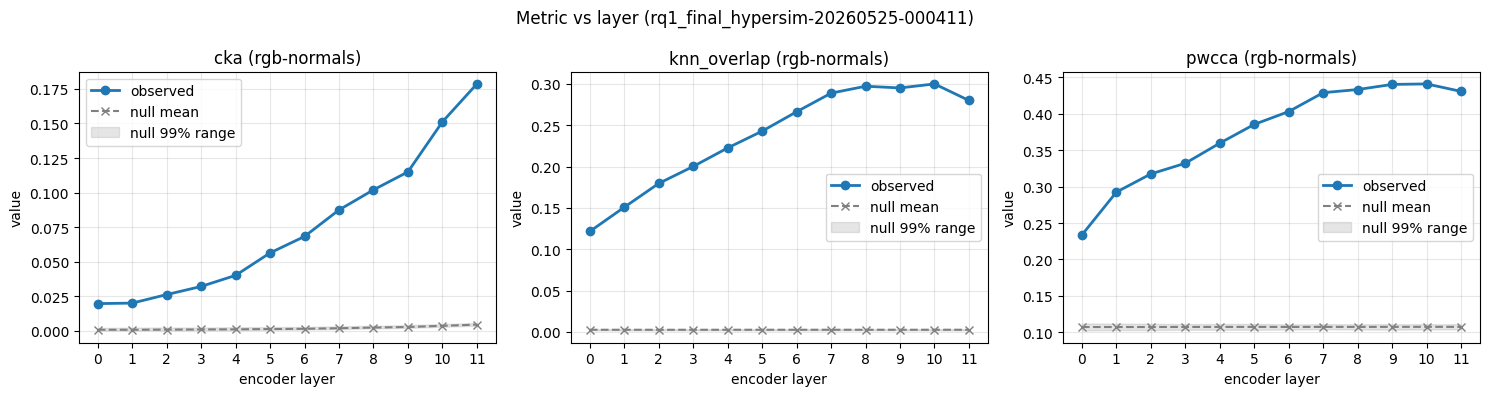

In [4]:
# Per-metric: observed value vs layer, with null mean and 95% range overlay where available.
metrics_with_null = set(null_df["metric"].unique())
metric_names = sorted(metrics["metric"].unique())
pairs = sorted(metrics["pair"].unique())

for pair in pairs:
    fig, axes = plt.subplots(1, len(metric_names), figsize=(5 * len(metric_names), 4))
    if len(metric_names) == 1:
        axes = [axes]

    for ax, m in zip(axes, metric_names):
        sub = metrics[(metrics["metric"] == m) & (metrics["pair"] == pair)].sort_values("layer_idx")
        if sub.empty:
            ax.set_title(f"{m} (no data)")
            ax.axis("off")
            continue

        layers = sub["layer_idx"].to_numpy()
        values = sub["value"].to_numpy()
        ax.plot(layers, values, marker="o", linewidth=2, label="observed")

        if m in metrics_with_null:
            null_sub = null_df[(null_df["metric"] == m) & (null_df["pair"] == pair)]
            if "null_mean" in sub.columns and sub["null_mean"].notna().any():
                ax.plot(layers, sub["null_mean"].to_numpy(), marker="x", linestyle="--", color="grey", label="null mean")
            if not null_sub.empty:
                bands = (
                    null_sub.groupby("layer_idx")["null_value"]
                    .agg(lo=lambda x: np.quantile(x, 0.005), hi=lambda x: np.quantile(x, 0.995))
                    .reset_index()
                    .sort_values("layer_idx")
                )
                ax.fill_between(bands["layer_idx"], bands["lo"], bands["hi"], color="grey", alpha=0.2, label="null 99% range")

        ax.set_title(f"{m} ({pair})")
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("value")
        ax.set_xticks(layers)
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

    fig.suptitle(f"Metric vs layer ({RUN_ID})")
    fig.tight_layout()
    plt.show()

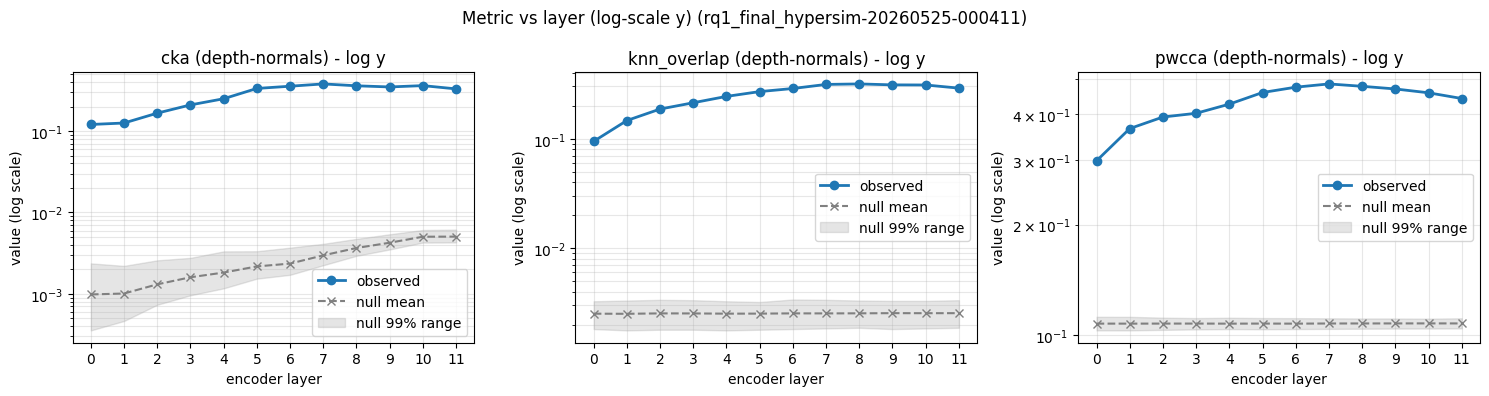

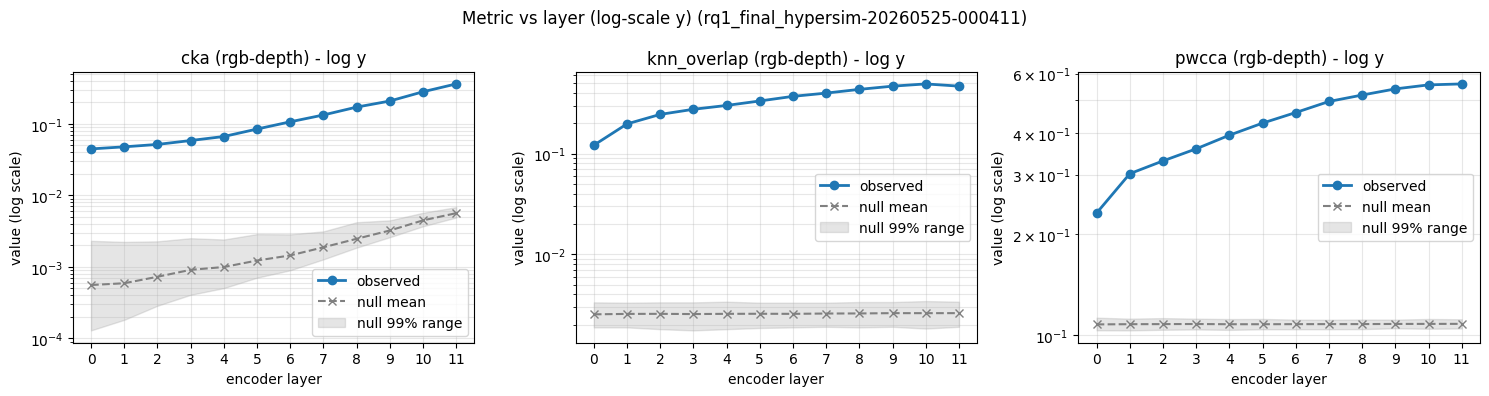

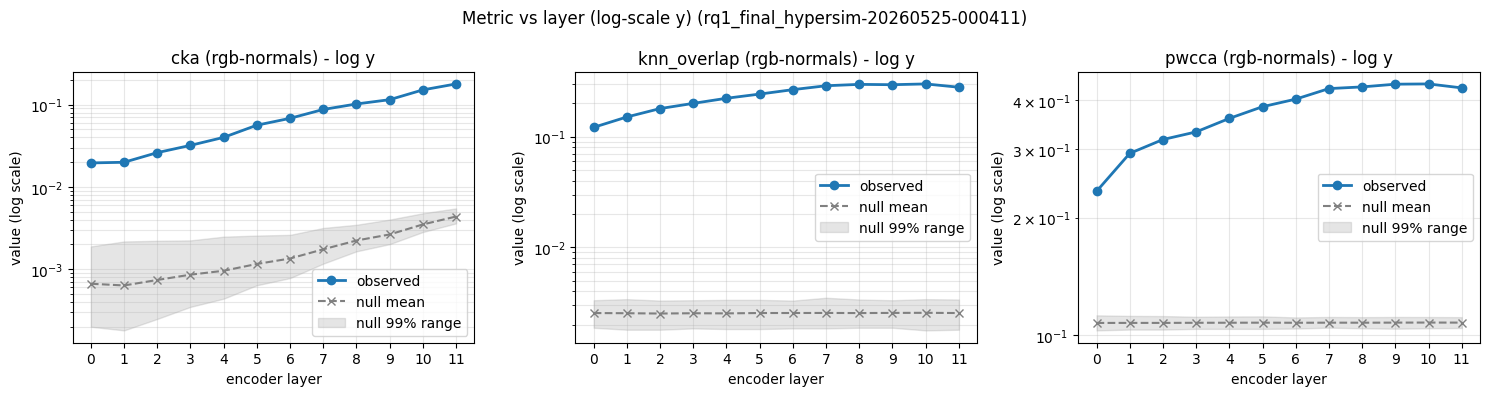

In [5]:
# Same plot as above, but with log-scale y-axis for readability near small null values.
EPS = 1e-12

for pair in pairs:
    fig, axes = plt.subplots(1, len(metric_names), figsize=(5 * len(metric_names), 4))
    if len(metric_names) == 1:
        axes = [axes]

    for ax, m in zip(axes, metric_names):
        sub = metrics[(metrics["metric"] == m) & (metrics["pair"] == pair)].sort_values("layer_idx")
        if sub.empty:
            ax.set_title(f"{m} (no data)")
            ax.axis("off")
            continue

        layers = sub["layer_idx"].to_numpy()
        values = np.maximum(sub["value"].to_numpy(dtype=float), EPS)
        ax.plot(layers, values, marker="o", linewidth=2, label="observed")

        if m in metrics_with_null:
            null_sub = null_df[(null_df["metric"] == m) & (null_df["pair"] == pair)]
            if "null_mean" in sub.columns and sub["null_mean"].notna().any():
                null_mean = np.maximum(sub["null_mean"].to_numpy(dtype=float), EPS)
                ax.plot(layers, null_mean, marker="x", linestyle="--", color="grey", label="null mean")

            if not null_sub.empty:
                bands = (
                    null_sub.groupby("layer_idx")["null_value"]
                    .agg(lo=lambda x: np.quantile(x, 0.005), hi=lambda x: np.quantile(x, 0.995))
                    .reset_index()
                    .sort_values("layer_idx")
                )
                lo = np.maximum(bands["lo"].to_numpy(dtype=float), EPS)
                hi = np.maximum(bands["hi"].to_numpy(dtype=float), EPS)
                ax.fill_between(bands["layer_idx"], lo, hi, color="grey", alpha=0.2, label="null 99% range")

        ax.set_yscale("log")
        ax.set_title(f"{m} ({pair}) - log y")
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("value (log scale)")
        ax.set_xticks(layers)
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3, which="both")

    fig.suptitle(f"Metric vs layer (log-scale y) ({RUN_ID})")
    fig.tight_layout()
    plt.show()

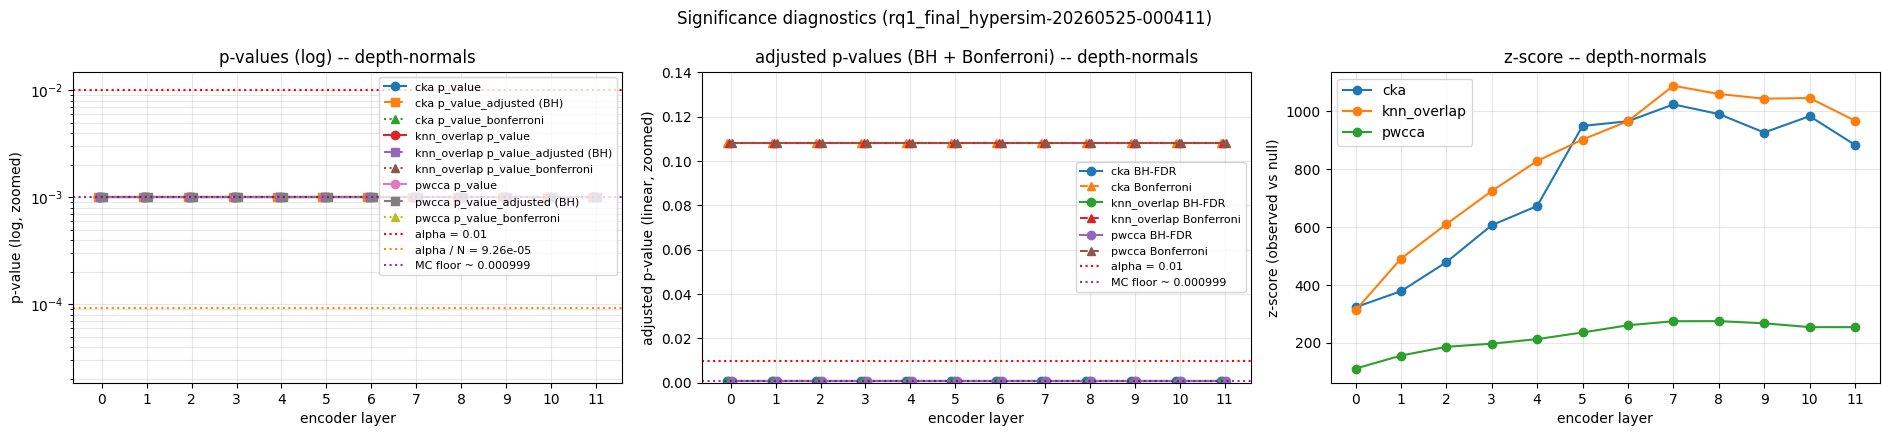

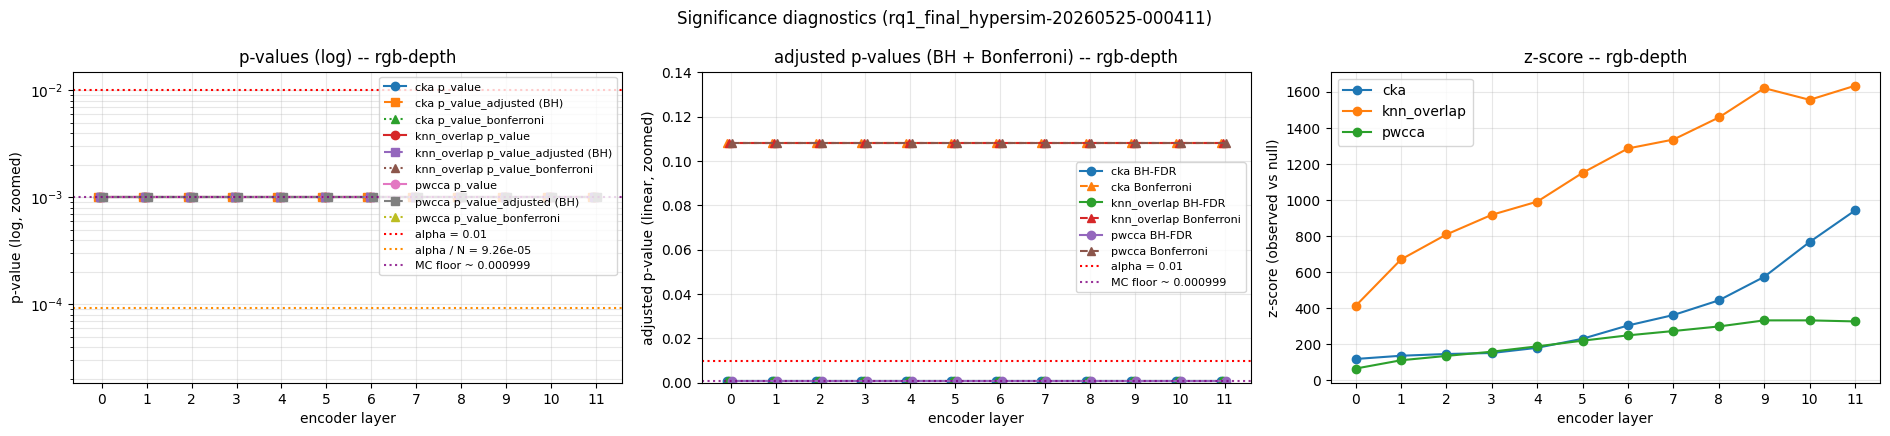

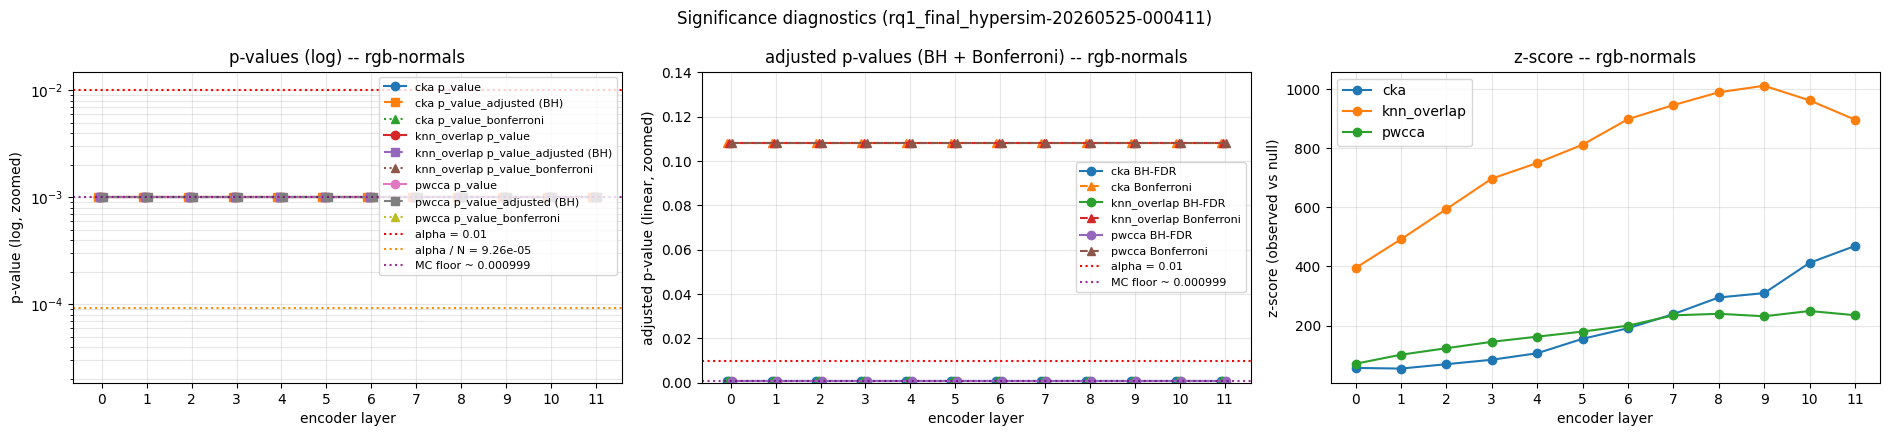

In [6]:
# p-value (log), adjusted p-value (linear, BH-FDR + Bonferroni), and z-score vs layer.
sig_df = metrics.dropna(subset=["p_value"]).copy()

if sig_df.empty:
    print("No p-values found in metrics.csv -- null distribution may not be computed for any metric.")
else:
    sig_metrics = sorted(sig_df["metric"].unique())
    sig_pairs = sorted(sig_df["pair"].unique())
    eps = 1e-12

    draw_counts = (
        null_df.groupby(["pair", "metric", "layer"]).size().rename("n_draws").reset_index()
        if not null_df.empty
        else pd.DataFrame(columns=["pair", "metric", "layer", "n_draws"])
    )

    for pair in sig_pairs:
        pair_df = sig_df[sig_df["pair"] == pair]
        if pair_df.empty:
            continue

        pair_draws = draw_counts[draw_counts["pair"] == pair]
        min_draws = int(pair_draws["n_draws"].min()) if not pair_draws.empty else 0
        p_floor = 1.0 / (min_draws + 1) if min_draws > 0 else np.nan

        fig, axes = plt.subplots(1, 3, figsize=(19, 4.4))

        # 1) Raw + adjusted (BH) + Bonferroni p-values on log scale
        ax = axes[0]
        for i, m in enumerate(sig_metrics):
            sub = pair_df[pair_df["metric"] == m].sort_values("layer_idx")
            if sub.empty:
                continue
            x = sub["layer_idx"].to_numpy(dtype=float) + (i - len(sig_metrics) / 2) * 0.06
            ax.plot(x, sub["p_value"], marker="o", label=f"{m} p_value")
            if "p_value_adjusted" in sub.columns and sub["p_value_adjusted"].notna().any():
                ax.plot(
                    x,
                    sub["p_value_adjusted"],
                    marker="s",
                    linestyle="--",
                    label=f"{m} p_value_adjusted (BH)",
                )
            if "p_value_bonferroni" in sub.columns and sub["p_value_bonferroni"].notna().any():
                ax.plot(
                    x,
                    sub["p_value_bonferroni"],
                    marker="^",
                    linestyle=":",
                    label=f"{m} p_value_bonferroni",
                )
        ax.axhline(ALPHA, linestyle=":", color="red", label=f"alpha = {ALPHA}")
        ax.axhline(
            ALPHA_BONFERRONI,
            linestyle=":",
            color="darkorange",
            label=f"alpha / N = {ALPHA_BONFERRONI:.2e}",
        )
        ax.set_yscale("log")
        # Zoom near tiny p-values to avoid a flat-looking line at the bottom.
        ax.set_ylim(min(ALPHA_BONFERRONI / 5, 1e-4), max(ALPHA * 1.5, 2e-3))
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("p-value (log, zoomed)")
        if np.isfinite(p_floor):
            ax.axhline(p_floor, linestyle=":", color="purple", alpha=0.8, label=f"MC floor ~ {p_floor:.3g}")
        ax.set_xticks(sorted(pair_df["layer_idx"].unique()))
        ax.set_title(f"p-values (log) -- {pair}")
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3, which="both")

        # 2) Adjusted (BH) and Bonferroni p-values on linear scale
        ax = axes[1]
        has_adjusted = False
        max_adj = 0.0
        for i, m in enumerate(sig_metrics):
            sub = pair_df[pair_df["metric"] == m].sort_values("layer_idx")
            if sub.empty:
                continue
            x = sub["layer_idx"].to_numpy(dtype=float) + (i - len(sig_metrics) / 2) * 0.06
            if "p_value_adjusted" in sub.columns and sub["p_value_adjusted"].notna().any():
                has_adjusted = True
                y = sub["p_value_adjusted"].to_numpy(dtype=float)
                ax.plot(x, y, marker="o", label=f"{m} BH-FDR")
                max_adj = max(max_adj, float(np.nanmax(y)))
            if "p_value_bonferroni" in sub.columns and sub["p_value_bonferroni"].notna().any():
                has_adjusted = True
                y = sub["p_value_bonferroni"].to_numpy(dtype=float)
                ax.plot(x, y, marker="^", linestyle="--", label=f"{m} Bonferroni")
                max_adj = max(max_adj, float(np.nanmax(y)))
        ax.axhline(ALPHA, linestyle=":", color="red", label=f"alpha = {ALPHA}")
        if np.isfinite(p_floor):
            ax.axhline(p_floor, linestyle=":", color="purple", alpha=0.8, label=f"MC floor ~ {p_floor:.3g}")
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("adjusted p-value (linear, zoomed)")
        ax.set_xticks(sorted(pair_df["layer_idx"].unique()))
        ax.set_ylim(0.0, max(ALPHA * 1.2, max_adj * 1.3 if max_adj > 0 else 0.02, (p_floor * 8) if np.isfinite(p_floor) else 0.0))
        ax.set_title(f"adjusted p-values (BH + Bonferroni) -- {pair}")
        if has_adjusted:
            ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)

        # 3) z-score
        ax = axes[2]
        has_z = False
        for m in sig_metrics:
            sub = pair_df[pair_df["metric"] == m].sort_values("layer_idx")
            if sub.empty or "z_score" not in sub.columns or not sub["z_score"].notna().any():
                continue
            has_z = True
            ax.plot(sub["layer_idx"], sub["z_score"], marker="o", label=m)
        ax.set_xlabel("encoder layer")
        ax.set_ylabel("z-score (observed vs null)")
        ax.set_xticks(sorted(pair_df["layer_idx"].unique()))
        ax.set_title(f"z-score -- {pair}")
        if has_z:
            ax.legend(loc="best")
        ax.grid(True, alpha=0.3)

        fig.suptitle(f"Significance diagnostics ({RUN_ID})")
        fig.tight_layout()
        plt.show()


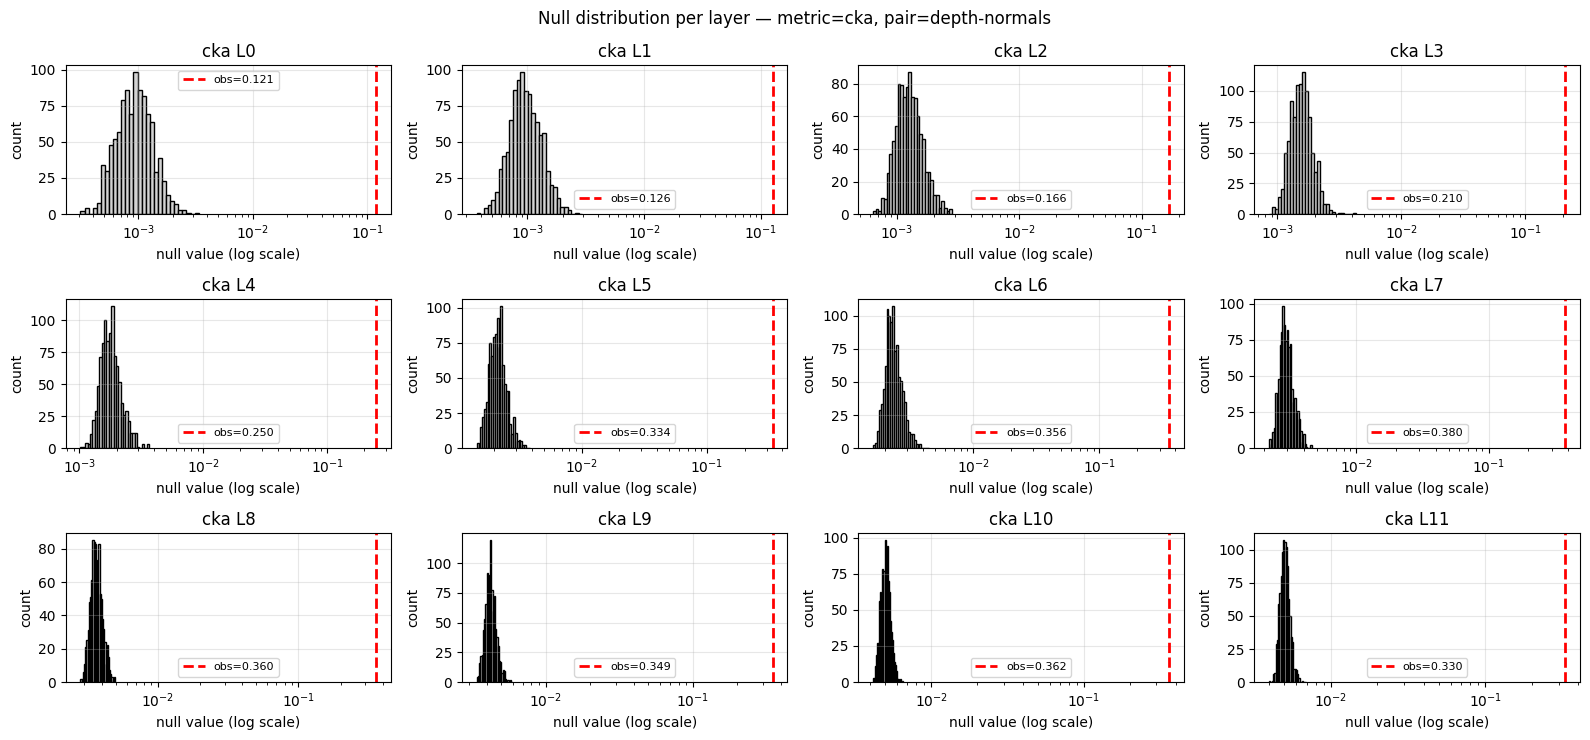

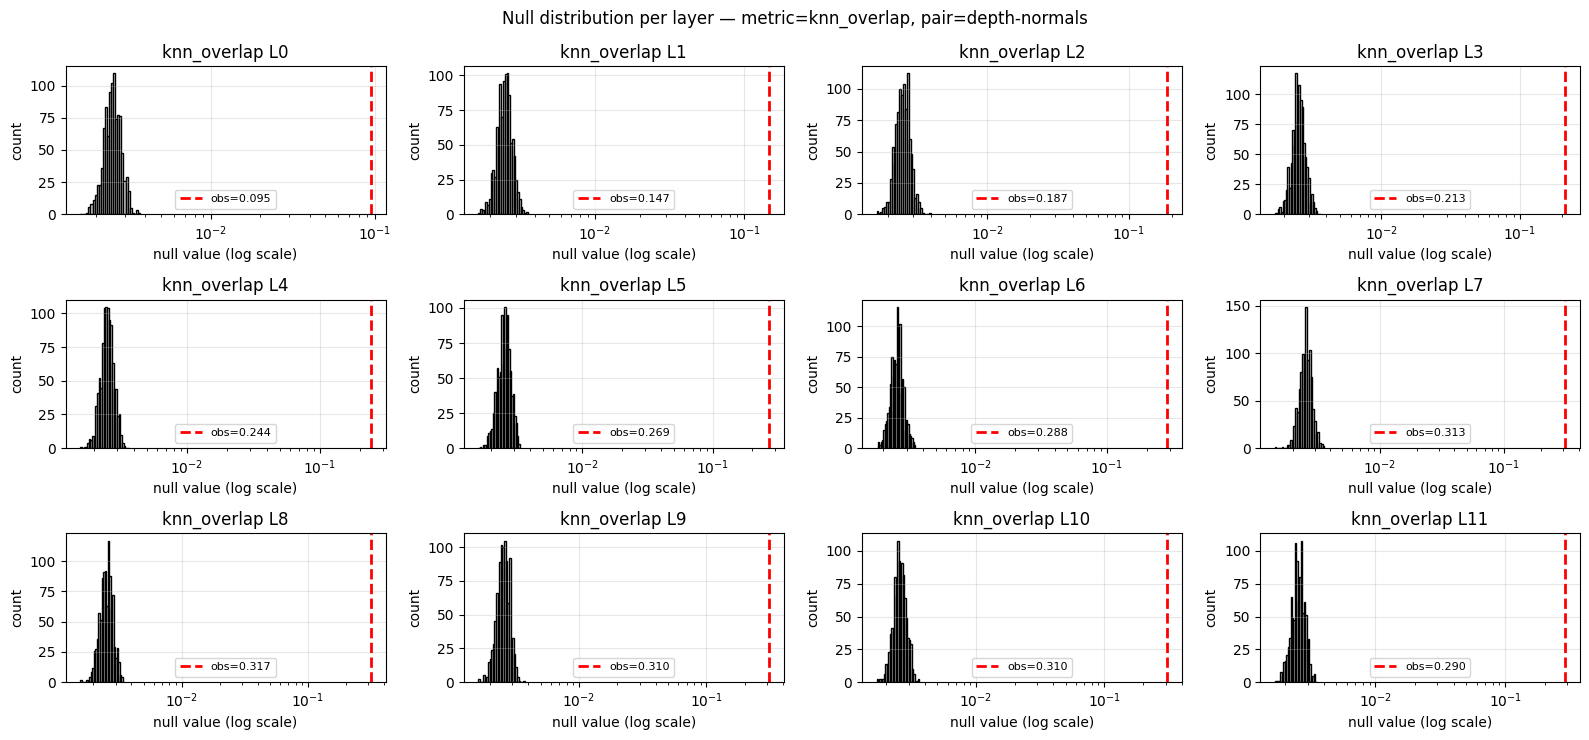

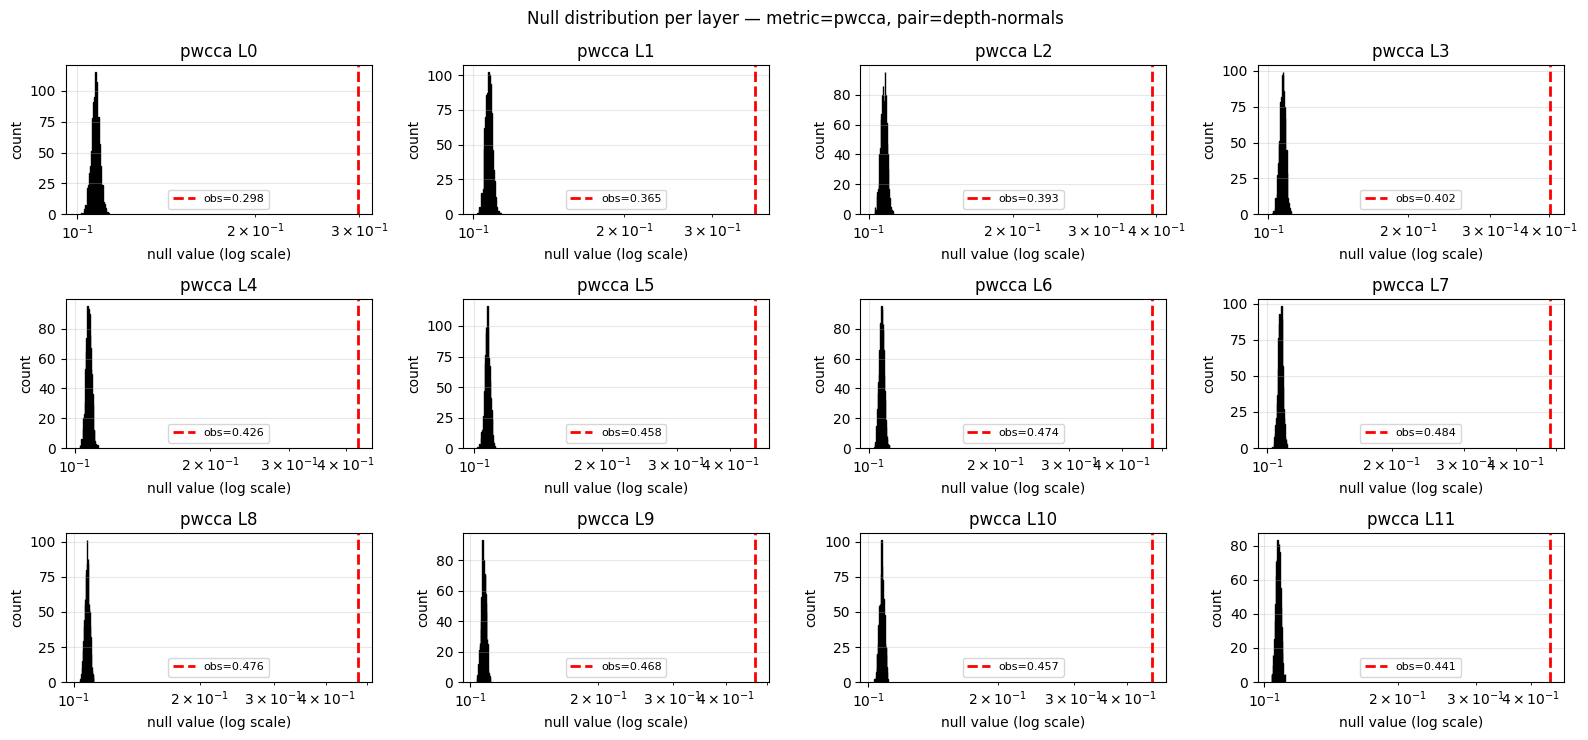

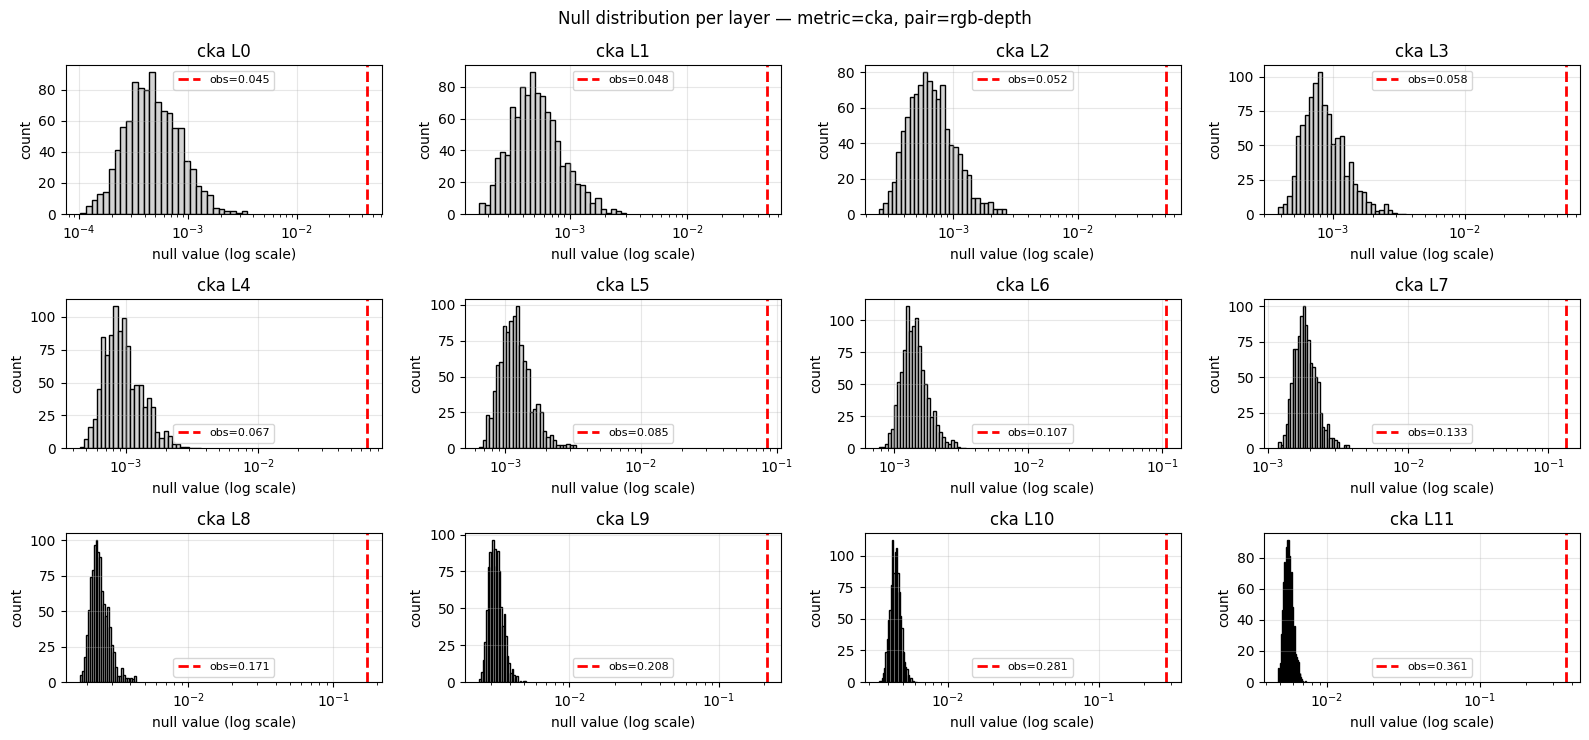

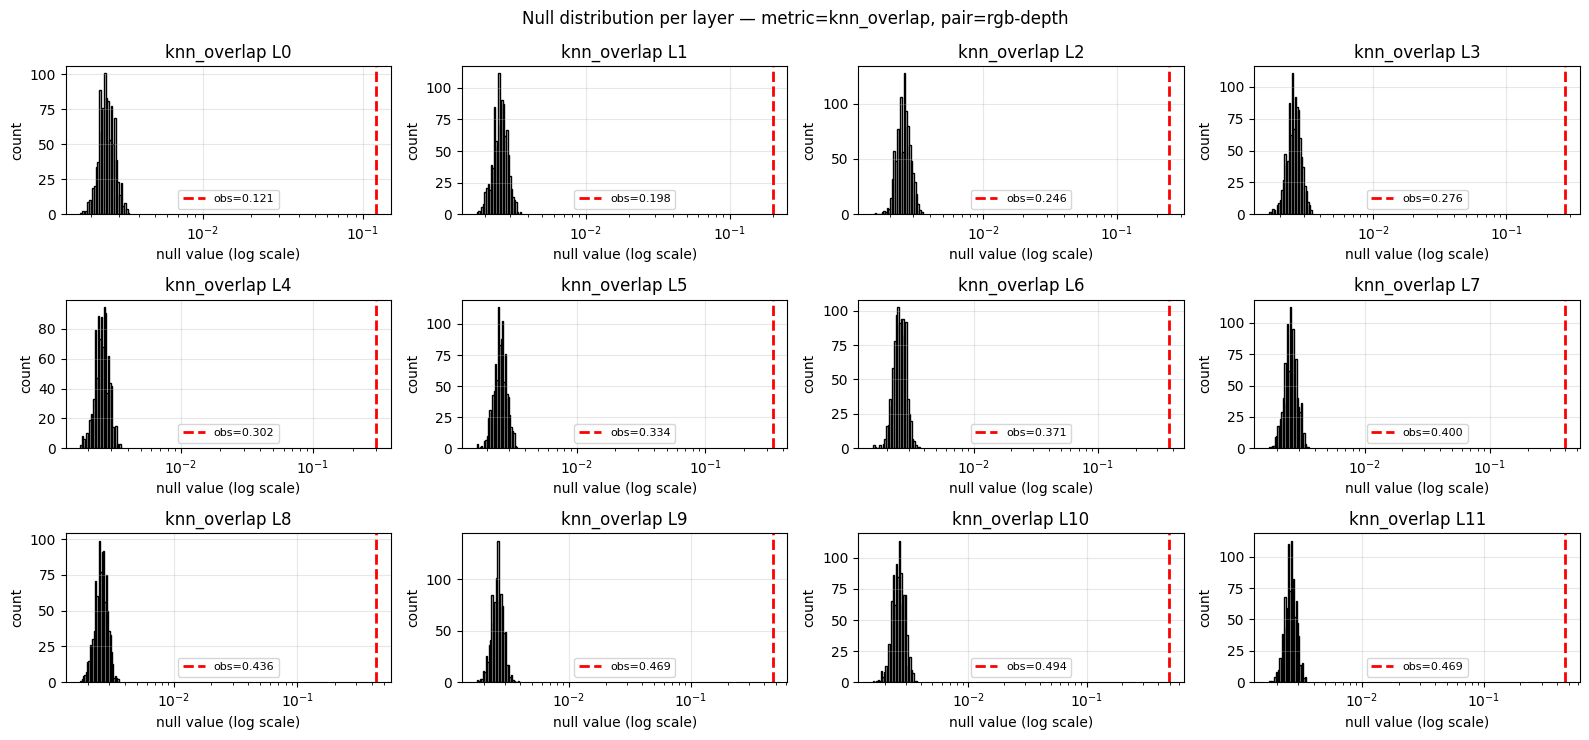

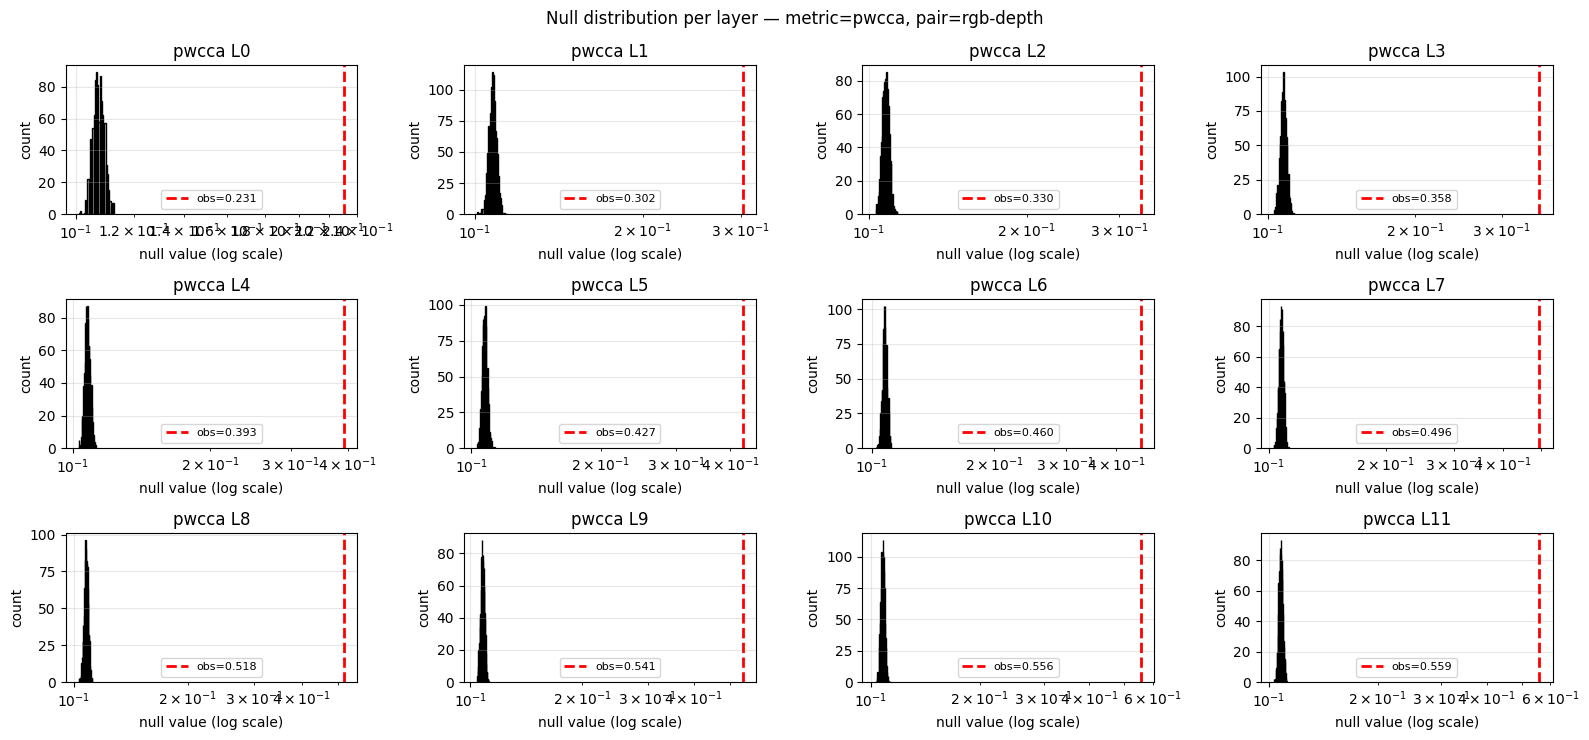

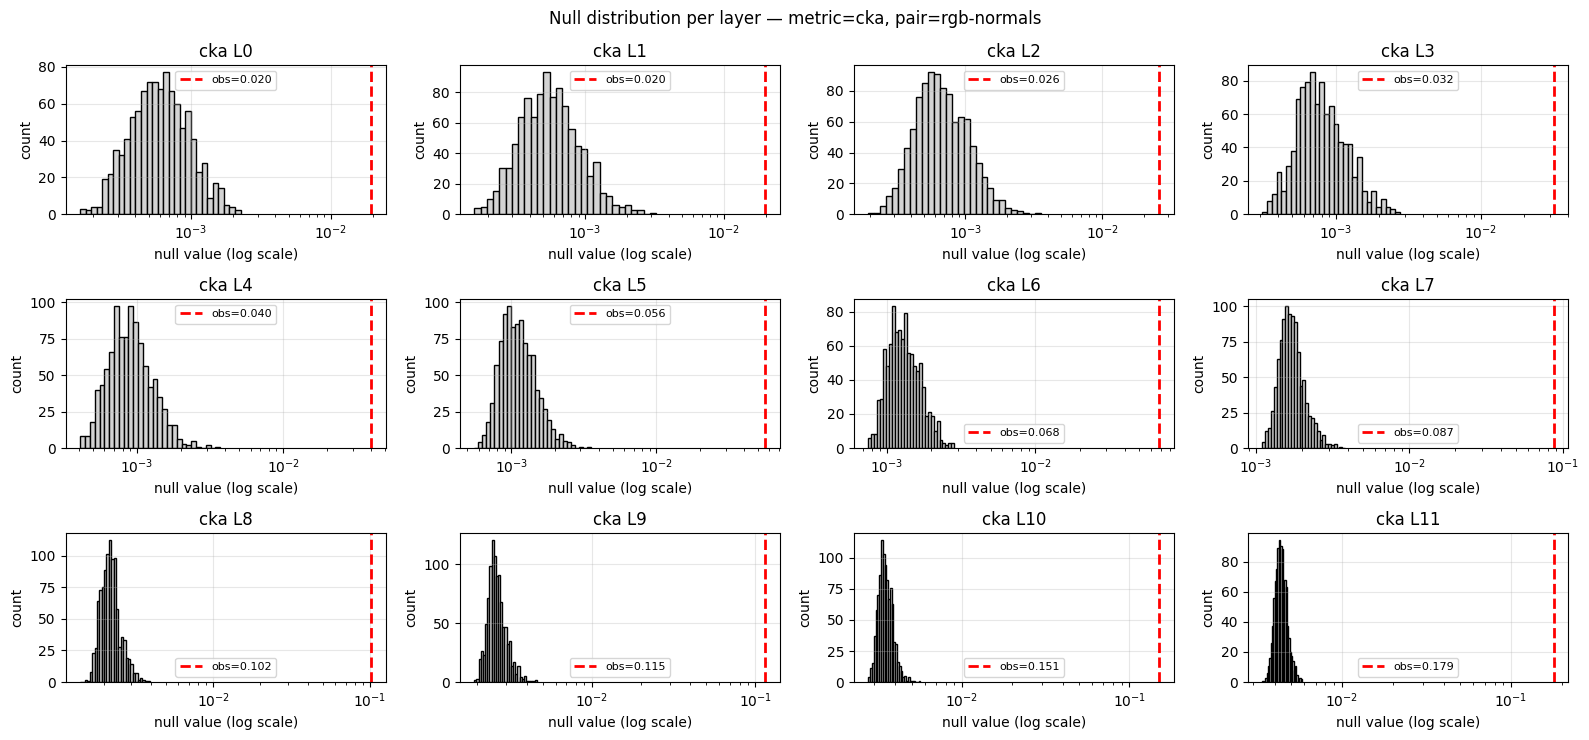

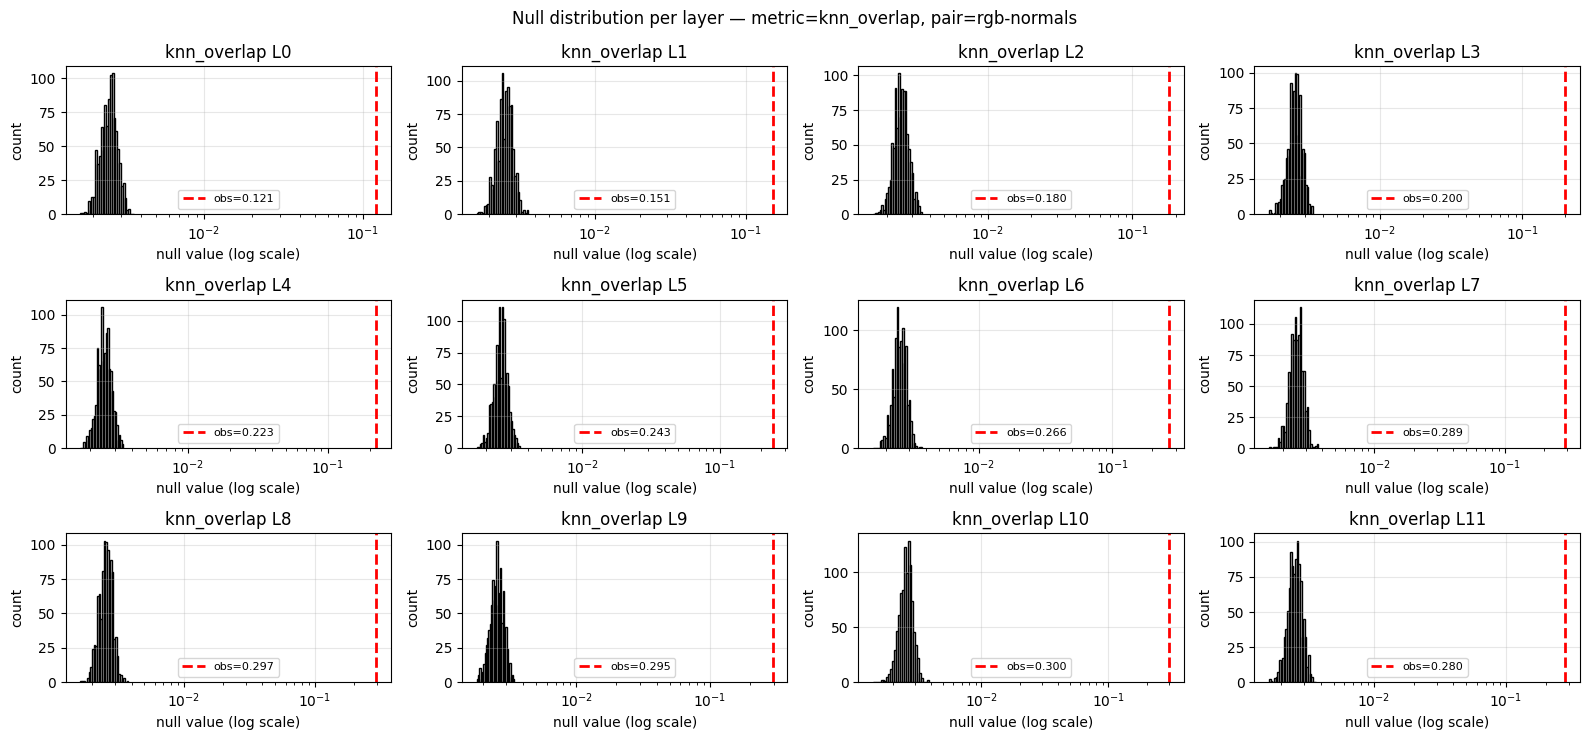

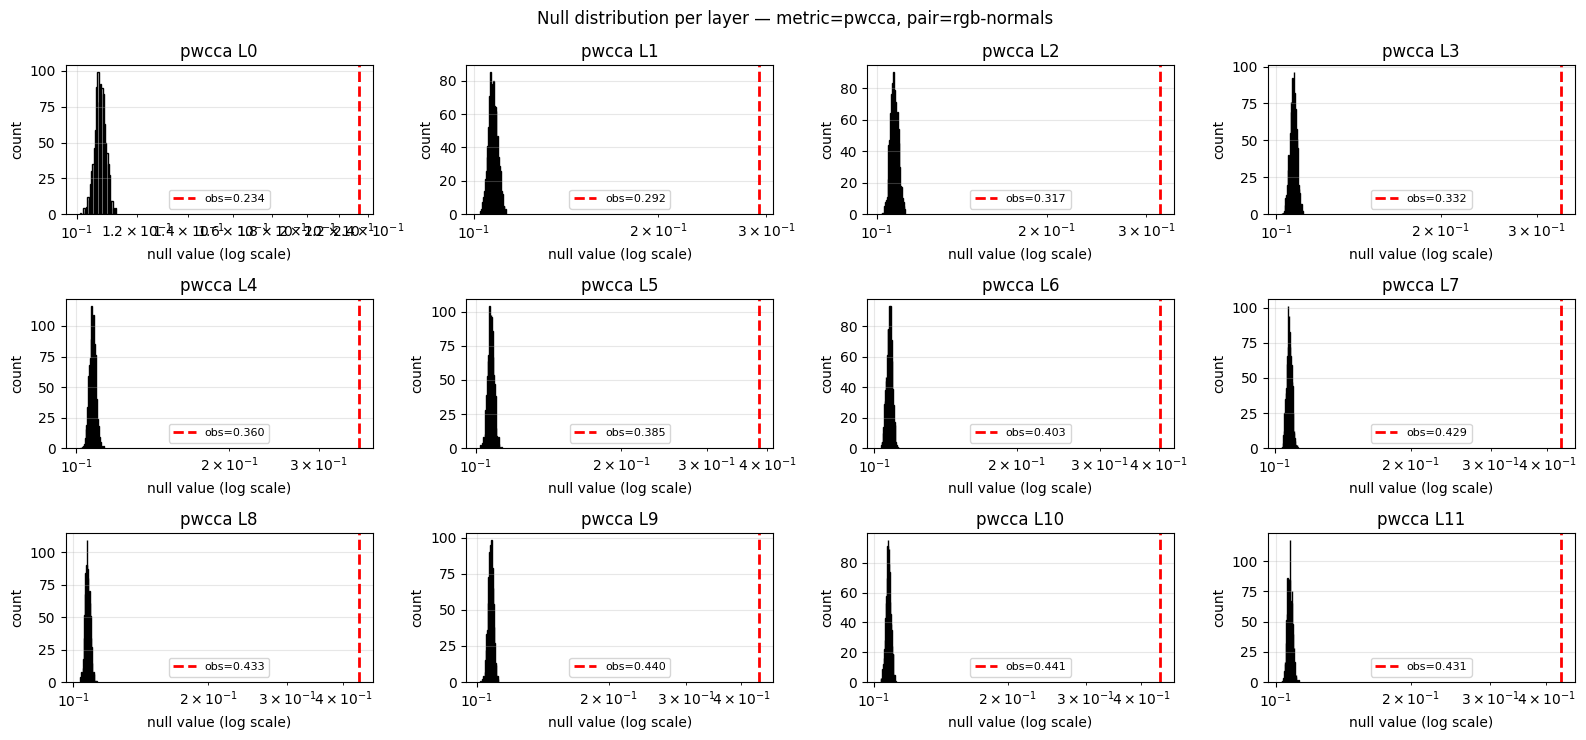

In [7]:
# Per-layer null distribution histograms with the observed value marked.
for pair in sorted(null_df["pair"].unique()):
    for m in sorted(null_df.loc[null_df["pair"] == pair, "metric"].unique()):
        null_sub = null_df[(null_df["metric"] == m) & (null_df["pair"] == pair)]
        obs_sub = metrics[(metrics["metric"] == m) & (metrics["pair"] == pair)]
        layers = sorted(null_sub["layer_idx"].unique())
        n = len(layers)
        cols = 4
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.5 * rows))
        axes = np.atleast_2d(axes)

        for idx, lid in enumerate(layers):
            ax = axes[idx // cols, idx % cols]
            null_vals = null_sub.loc[null_sub["layer_idx"] == lid, "null_value"].to_numpy(dtype=float)
            pos_vals = null_vals[null_vals > 0]
            if len(pos_vals) > 0 and float(pos_vals.max()) > float(pos_vals.min()):
                bins = np.logspace(np.log10(pos_vals.min()), np.log10(pos_vals.max()), 30)
                ax.hist(pos_vals, bins=bins, color="lightgrey", edgecolor="black")
                ax.set_xscale("log")
            else:
                ax.hist(null_vals, bins=30, color="lightgrey", edgecolor="black")

            obs_row = obs_sub[obs_sub["layer_idx"] == lid]
            if not obs_row.empty:
                obs_val = float(obs_row["value"].iloc[0])
                if obs_val > 0:
                    ax.axvline(obs_val, color="red", linestyle="--", linewidth=2, label=f"obs={obs_val:.3f}")
                    ax.legend(loc="best", fontsize=8)
            ax.set_title(f"{m} L{lid}")
            ax.set_xlabel("null value (log scale)")
            ax.set_ylabel("count")
            ax.grid(True, alpha=0.3)

        for idx in range(n, rows * cols):
            axes[idx // cols, idx % cols].axis("off")

        fig.suptitle(f"Null distribution per layer — metric={m}, pair={pair}")
        fig.tight_layout()
        plt.show()

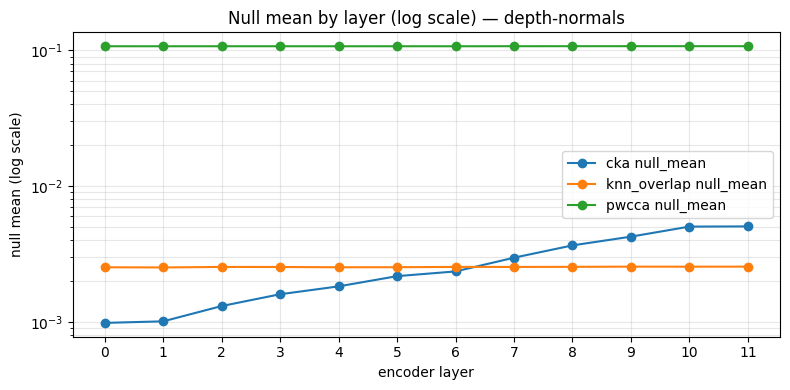

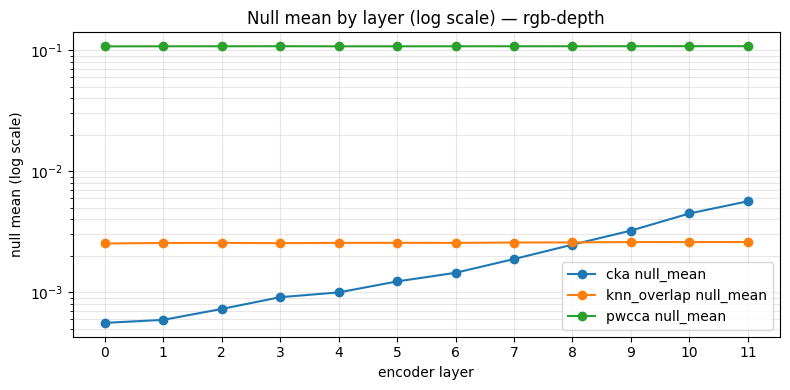

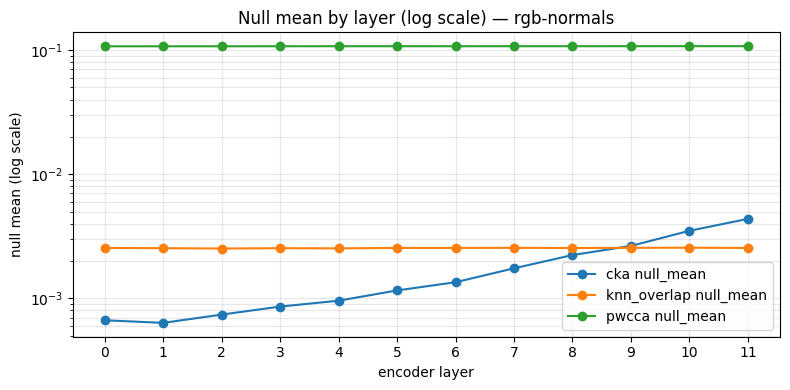

Tip: if values are very close, compare with null_std or use log10(null_mean) explicitly.


In [8]:
# Null mean on log scale (requested): helps inspect tiny but non-zero null baselines.
null_stats = (
    null_df.groupby(["pair", "metric", "layer", "layer_idx"]) ["null_value"]
    .agg(null_mean="mean", null_std="std")
    .reset_index()
    .sort_values(["pair", "metric", "layer_idx"])
)

for pair in sorted(null_stats["pair"].unique()):
    pair_stats = null_stats[null_stats["pair"] == pair]
    fig, ax = plt.subplots(figsize=(8, 4))
    for m in sorted(pair_stats["metric"].unique()):
        sub = pair_stats[pair_stats["metric"] == m].sort_values("layer_idx")
        if sub.empty:
            continue
        ax.plot(sub["layer_idx"], sub["null_mean"], marker="o", label=f"{m} null_mean")

    ax.set_yscale("log")
    ax.set_xlabel("encoder layer")
    ax.set_ylabel("null mean (log scale)")
    ax.set_xticks(sorted(pair_stats["layer_idx"].unique()))
    ax.set_title(f"Null mean by layer (log scale) — {pair}")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("Tip: if values are very close, compare with null_std or use log10(null_mean) explicitly.")

In [9]:
# Optional diagnostics: scene-type enrichment in the high-null tail.
# Helps detect scene types that dominate large null values, which would
# bias the null distribution.
TAILS = [0.95, 0.99]


def side_enrichment(df_all: pd.DataFrame, df_tail: pd.DataFrame) -> pd.DataFrame:
    all_side = pd.concat([
        df_all[["left_scene_type"]].rename(columns={"left_scene_type": "scene_type"}),
        df_all[["right_scene_type"]].rename(columns={"right_scene_type": "scene_type"}),
    ], ignore_index=True)
    tail_side = pd.concat([
        df_tail[["left_scene_type"]].rename(columns={"left_scene_type": "scene_type"}),
        df_tail[["right_scene_type"]].rename(columns={"right_scene_type": "scene_type"}),
    ], ignore_index=True)

    all_counts = all_side["scene_type"].value_counts().rename("all_count")
    tail_counts = tail_side["scene_type"].value_counts().rename("tail_count")

    out = pd.concat([all_counts, tail_counts], axis=1).fillna(0)
    out["all_count"] = out["all_count"].astype(int)
    out["tail_count"] = out["tail_count"].astype(int)
    out["all_rate"] = out["all_count"] / max(out["all_count"].sum(), 1)
    out["tail_rate"] = out["tail_count"] / max(out["tail_count"].sum(), 1)
    out["lift"] = out["tail_rate"] / out["all_rate"].replace(0, np.nan)
    return (
        out.reset_index()
        .rename(columns={"index": "scene_type"})
        .sort_values("lift", ascending=False)
    )


out_root = project_root / "results" / "runs" / RUN_ID / "diagnostics"
out_root.mkdir(parents=True, exist_ok=True)

for metric_name in sorted(null_df["metric"].unique()):
    print(f"\n=== Metric: {metric_name} ===")
    dnull = null_df[null_df["metric"] == metric_name].copy()
    for q in TAILS:
        thr = float(dnull["null_value"].quantile(q))
        tail = dnull[dnull["null_value"] >= thr]
        print(f"\nTop {int((1 - q) * 100)}% tail (q={q}, threshold={thr:.4f}, n={len(tail)}):")
        enr = side_enrichment(dnull, tail)
        display(enr.head(10))
        enr.to_csv(out_root / f"{metric_name}_scene_type_enrichment_q{int(q*100)}.csv", index=False)
        tail.to_csv(out_root / f"{metric_name}_null_q{int(q*100)}_tail.csv", index=False)

print(f"\nDiagnostic CSVs saved under: {out_root}")


=== Metric: cka ===

Top 5% tail (q=0.95, threshold=0.0051, n=1800):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
22,Transit station,1330,75,0.018472,0.020833,1.127820
18,Office (waiting area),2023,109,0.028097,0.030278,1.077608
6,Office,3744,201,0.052000,0.055833,1.073718
20,Office (conference room),1791,95,0.024875,0.026389,1.060860
1,Bedroom,5157,271,0.071625,0.075278,1.050999
17,Office (building foyer),2139,112,0.029708,0.031111,1.047218
9,Lecture theater,3083,160,0.042819,0.044444,1.037950
15,Hallway,2480,128,0.034444,0.035556,1.032258
0,Living room,5623,290,0.078097,0.080556,1.031478
11,Hall,2820,145,0.039167,0.040278,1.028369



Top 1% tail (q=0.99, threshold=0.0058, n=360):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
18,Office (waiting area),2023,25,0.028097,0.034722,1.235788
17,Office (building foyer),2139,26,0.029708,0.036111,1.215521
15,Hallway,2480,30,0.034444,0.041667,1.209677
22,Transit station,1330,16,0.018472,0.022222,1.203008
1,Bedroom,5157,60,0.071625,0.083333,1.163467
3,Dining room,4550,52,0.063194,0.072222,1.142857
9,Lecture theater,3083,35,0.042819,0.048611,1.135258
16,Art gallery,2334,25,0.032417,0.034722,1.071123
21,Retail space,1690,18,0.023472,0.025000,1.065089
20,Office (conference room),1791,19,0.024875,0.026389,1.060860



=== Metric: knn_overlap ===

Top 5% tail (q=0.95, threshold=0.0030, n=1963):


...


=== Metric: pwcca ===

Top 5% tail (q=0.95, threshold=0.1100, n=1800):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
4,Hotel lobby,4420,256,0.061389,0.071111,1.158371
8,Other,3147,176,0.043708,0.048889,1.118526
18,Office (waiting area),2018,112,0.028028,0.031111,1.110010
7,Staircase,3290,178,0.045694,0.049444,1.082067
6,Office,3714,200,0.051583,0.055556,1.077006
19,Courtyard,1976,106,0.027444,0.029444,1.072874
2,Office (home),4983,267,0.069208,0.074167,1.071644
1,Bedroom,5064,269,0.070333,0.074722,1.062401
16,Art gallery,2387,126,0.033153,0.035000,1.055718
12,OUTSIDE VIEWING AREA (BAD INITIALIZATION),2646,135,0.036750,0.037500,1.020408



Top 1% tail (q=0.99, threshold=0.1110, n=360):


,scene_type,all_count,tail_count,all_rate,tail_rate,lift
12,OUTSIDE VIEWING AREA (BAD INITIALIZATION),2646,39,0.036750,0.054167,1.473923
18,Office (waiting area),2018,25,0.028028,0.034722,1.238850
10,Restaurant,2915,36,0.040486,0.050000,1.234991
7,Staircase,3290,39,0.045694,0.054167,1.185410
19,Courtyard,1976,23,0.027444,0.031944,1.163968
8,Other,3147,36,0.043708,0.050000,1.143947
6,Office,3714,40,0.051583,0.055556,1.077006
1,Bedroom,5064,54,0.070333,0.075000,1.066351
15,Hallway,2482,26,0.034472,0.036111,1.047542
16,Art gallery,2387,25,0.033153,0.034722,1.047340



Diagnostic CSVs saved under: C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\rq1_final_hypersim-20260525-000411\diagnostics


In [10]:
# Common derived quantities used by the interpretation plots.
EPS = 1e-12

viz_df = metrics.copy()
if "null_mean" not in viz_df.columns:
    viz_df["null_mean"] = np.nan
if "null_std" not in viz_df.columns:
    viz_df["null_std"] = np.nan
if "p_value_adjusted" not in viz_df.columns:
    viz_df["p_value_adjusted"] = np.nan
if "p_value_bonferroni" not in viz_df.columns:
    viz_df["p_value_bonferroni"] = np.nan
if "z_score" not in viz_df.columns:
    viz_df["z_score"] = np.nan

viz_df["fold_change"] = viz_df["value"] / (viz_df["null_mean"].abs() + EPS)
viz_df["log10_fold_change"] = np.log10(np.maximum(viz_df["fold_change"], EPS))
viz_df["delta_vs_null"] = viz_df["value"] - viz_df["null_mean"]
viz_df["neglog10_p_adj"] = -np.log10(np.maximum(viz_df["p_value_adjusted"], EPS))
viz_df["neglog10_p_bonf"] = -np.log10(np.maximum(viz_df["p_value_bonferroni"], EPS))

display(
    viz_df[
        [
            "pair",
            "metric",
            "layer",
            "value",
            "null_mean",
            "null_std",
            "delta_vs_null",
            "z_score",
            "p_value",
            "p_value_adjusted",
            "p_value_bonferroni",
            "log10_fold_change",
        ]
    ].head()
)


,pair,metric,layer,value,null_mean,null_std,delta_vs_null,z_score,p_value,p_value_adjusted,p_value_bonferroni,log10_fold_change
0,depth-normals,cka,layer_00,0.120624,0.000982,0.000371,0.119641,322.588189,0.000999,0.000999,0.107892,2.089230
1,depth-normals,cka,layer_01,0.125713,0.001008,0.000330,0.124705,377.985631,0.000999,0.000999,0.107892,2.095783
2,depth-normals,cka,layer_02,0.166277,0.001307,0.000345,0.164969,478.492048,0.000999,0.000999,0.107892,2.104509
3,depth-normals,cka,layer_03,0.209872,0.001597,0.000344,0.208275,606.316636,0.000999,0.000999,0.107892,2.118641
4,depth-normals,cka,layer_04,0.249891,0.001825,0.000369,0.248066,672.732762,0.000999,0.000999,0.107892,2.136481


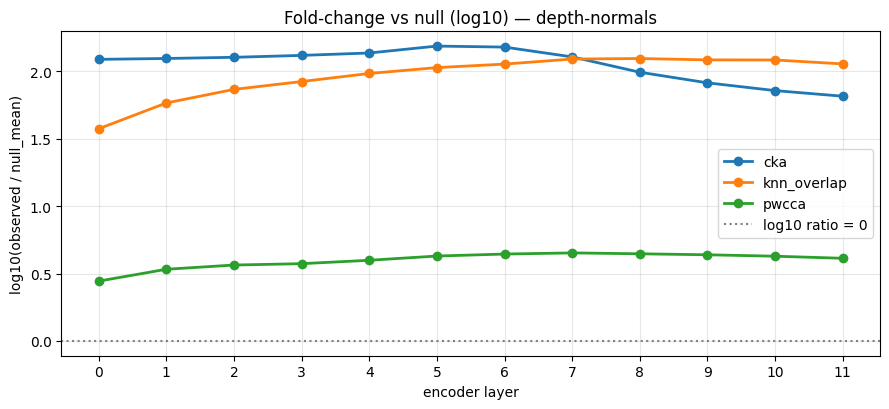

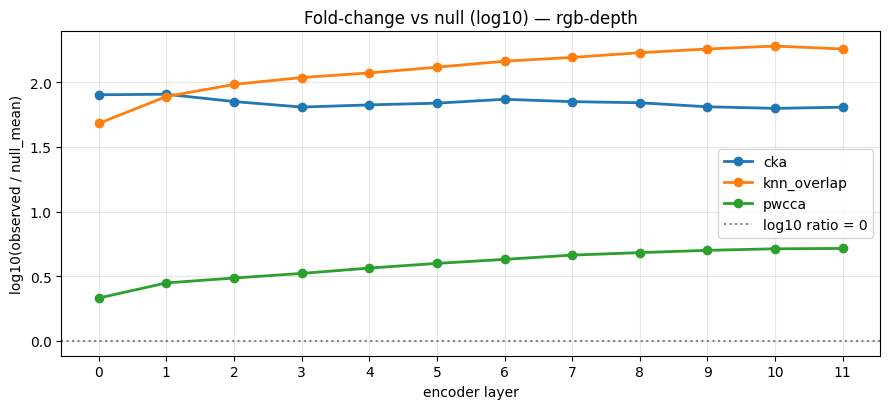

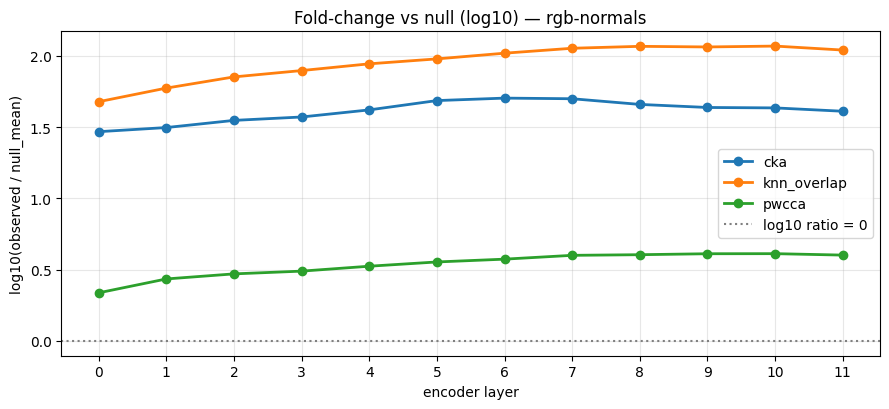

In [11]:
# 1) log10(observed / null_mean) vs layer.
for pair in sorted(viz_df["pair"].unique()):
    sub_pair = viz_df[viz_df["pair"] == pair]
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for m in sorted(sub_pair["metric"].unique()):
        sub = sub_pair[sub_pair["metric"] == m].sort_values("layer_idx")
        if sub["null_mean"].notna().sum() == 0:
            continue
        ax.plot(sub["layer_idx"], sub["log10_fold_change"], marker="o", linewidth=2, label=m)

    ax.axhline(0.0, linestyle=":", color="grey", label="log10 ratio = 0")
    ax.set_xlabel("encoder layer")
    ax.set_ylabel("log10(observed / null_mean)")
    ax.set_xticks(sorted(sub_pair["layer_idx"].unique()))
    ax.set_title(f"Fold-change vs null (log10) — {pair}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

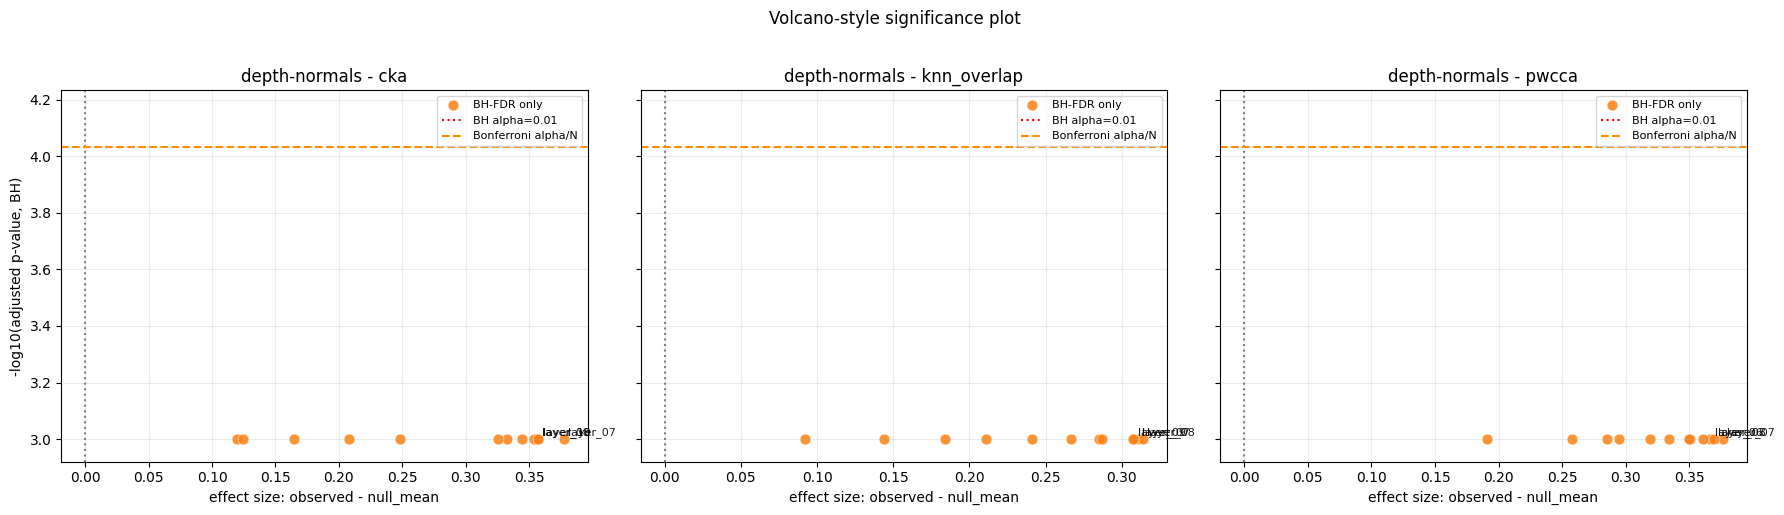

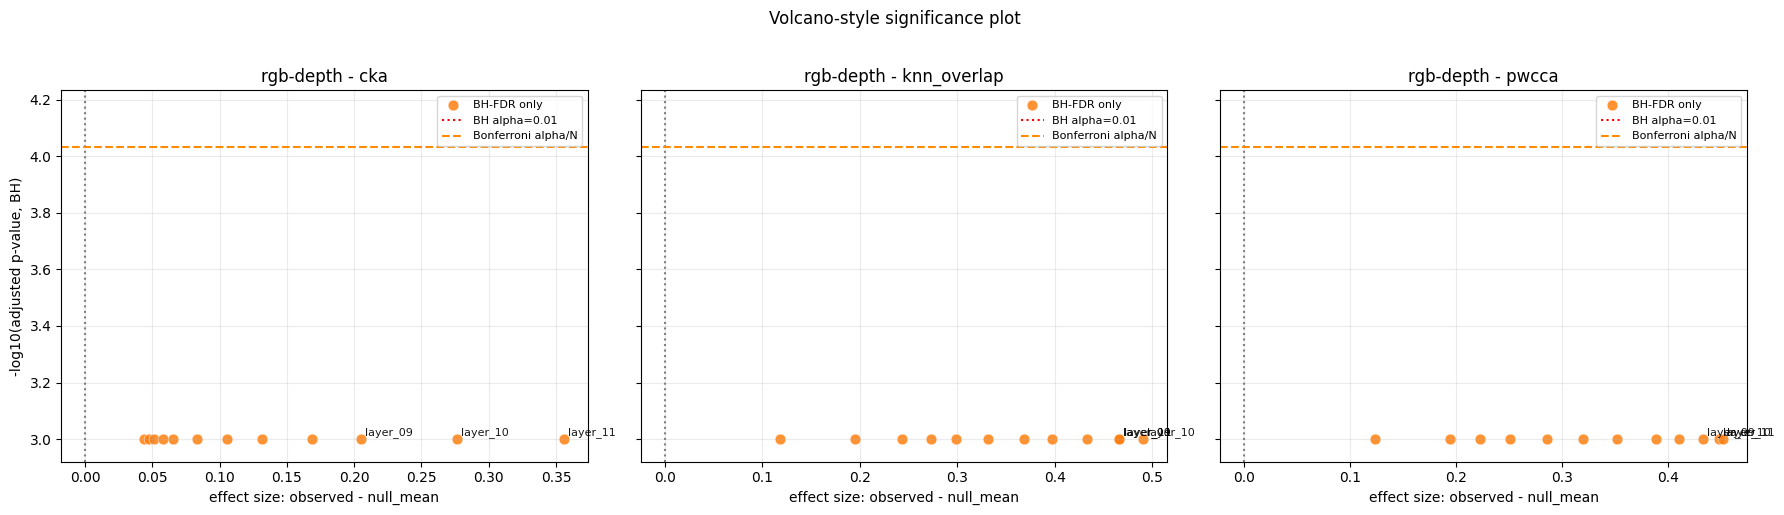

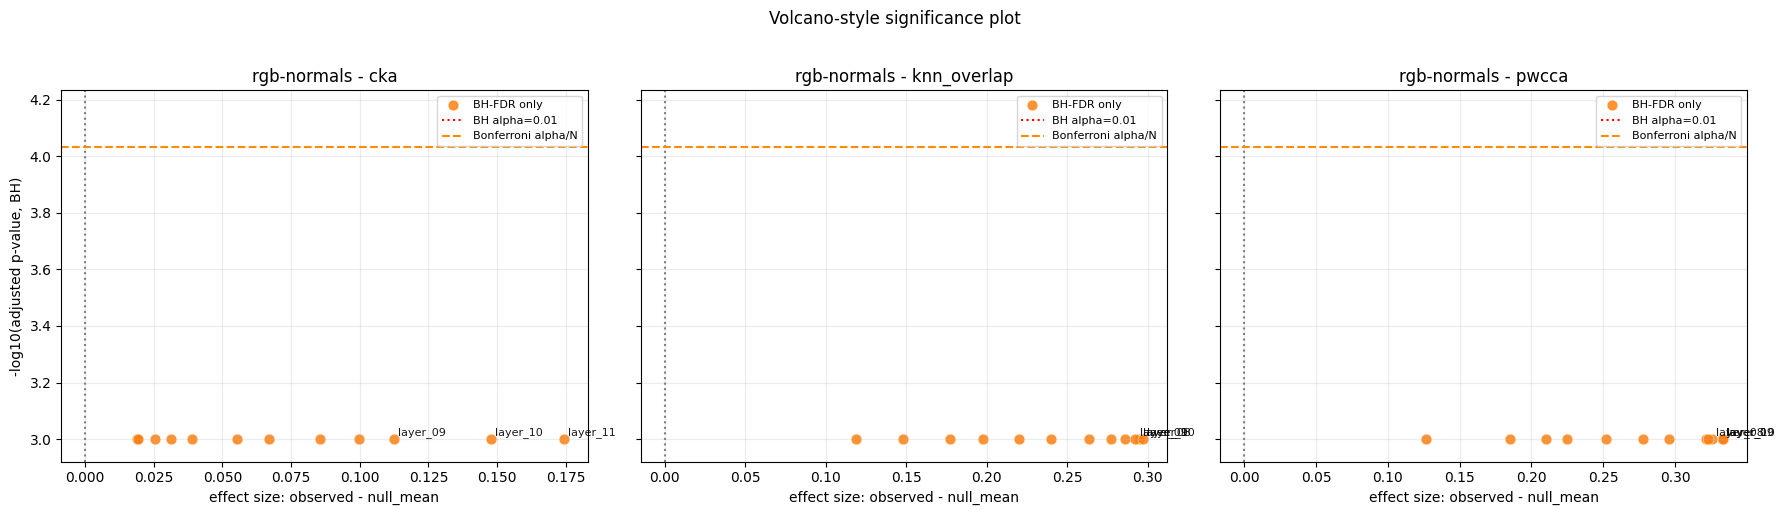

In [12]:
# 2) Volcano-like plot: effect size (delta) vs -log10(adjusted p-value).
# No y-jitter here: vertical spread reflects real p-value differences.
# Points are colour-coded by significance class (Bonferroni > BH-FDR > raw).
y_alpha_bh = -np.log10(ALPHA)
y_alpha_bonf = -np.log10(ALPHA_BONFERRONI)


def _significance_class(row):
    if row.get("is_significant_bonferroni", False):
        return "Bonferroni"
    if row.get("is_significant_bh_fdr", False):
        return "BH-FDR only"
    if pd.notna(row.get("p_value")) and row["p_value"] < ALPHA:
        return "raw only"
    return "non-sig"


_sig_palette = {
    "Bonferroni": "#d62728",       # strong red
    "BH-FDR only": "#ff7f0e",      # orange
    "raw only": "#1f77b4",         # blue
    "non-sig": "lightgrey",
}

for pair in sorted(viz_df["pair"].unique()):
    sub_pair = viz_df[viz_df["pair"] == pair].copy()
    sub_pair = sub_pair.dropna(subset=["delta_vs_null", "p_value_adjusted"])
    if sub_pair.empty:
        continue

    sub_pair["sig_class"] = sub_pair.apply(_significance_class, axis=1)

    metric_list = sorted(sub_pair["metric"].unique())
    n_cols = len(metric_list)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=True)
    if n_cols == 1:
        axes = [axes]

    all_y = sub_pair["neglog10_p_adj"].to_numpy(dtype=float)
    y_lo = float(np.nanmin(all_y)) if len(all_y) else 0.0
    y_hi = float(np.nanmax(all_y)) if len(all_y) else 1.0
    if (y_hi - y_lo) < 0.12:
        pad = 0.08
        y_lo = max(0.0, y_lo - pad)
        y_hi = max(y_hi, y_alpha_bonf) + pad

    for ax, m in zip(axes, metric_list):
        sub = sub_pair[sub_pair["metric"] == m].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        for sig_class, colour in _sig_palette.items():
            chunk = sub[sub["sig_class"] == sig_class]
            if chunk.empty:
                continue
            ax.scatter(
                chunk["delta_vs_null"],
                chunk["neglog10_p_adj"],
                s=60,
                alpha=0.85,
                edgecolors="white",
                linewidth=0.4,
                c=colour,
                label=sig_class,
            )

        label_candidates = sub.assign(_abs_delta=sub["delta_vs_null"].abs())
        to_label = label_candidates.nlargest(3, "_abs_delta")
        for _, row in to_label.iterrows():
            ax.annotate(
                str(row["layer"]),
                (row["delta_vs_null"], row["neglog10_p_adj"]),
                fontsize=8,
                alpha=0.9,
                xytext=(3, 3),
                textcoords="offset points",
            )

        ax.axvline(0.0, linestyle=":", color="grey")
        ax.axhline(y_alpha_bh, linestyle=":", color="red", label=f"BH alpha={ALPHA}")
        ax.axhline(
            y_alpha_bonf,
            linestyle="--",
            color="darkorange",
            label=f"Bonferroni alpha/N",
        )
        ax.set_ylim(y_lo, max(y_hi, y_alpha_bonf + 0.2))
        ax.set_title(f"{pair} - {m}")
        ax.set_xlabel("effect size: observed - null_mean")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=8)

    axes[0].set_ylabel("-log10(adjusted p-value, BH)")
    fig.suptitle("Volcano-style significance plot", y=1.02)
    plt.tight_layout()
    plt.show()


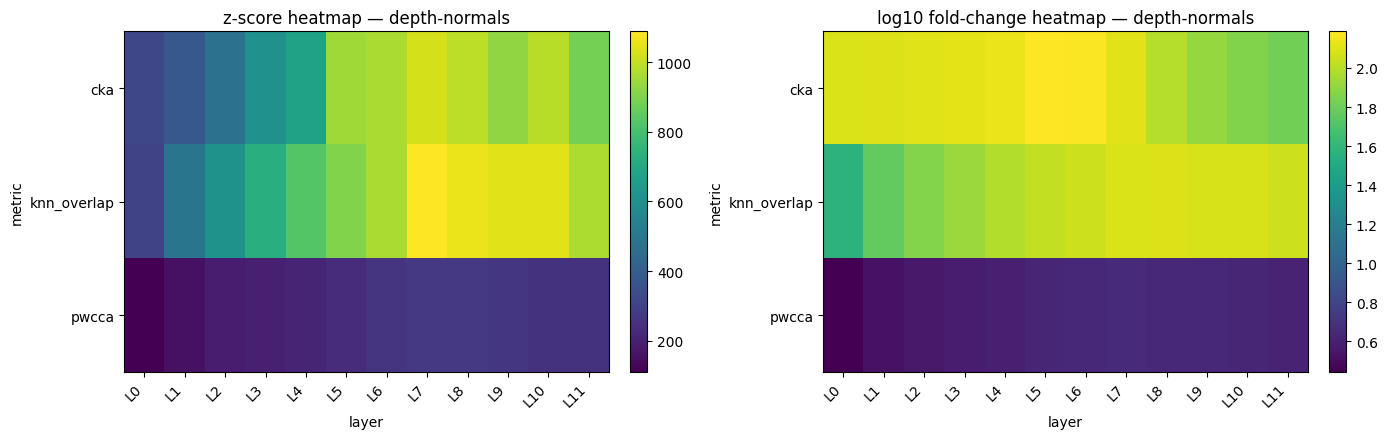

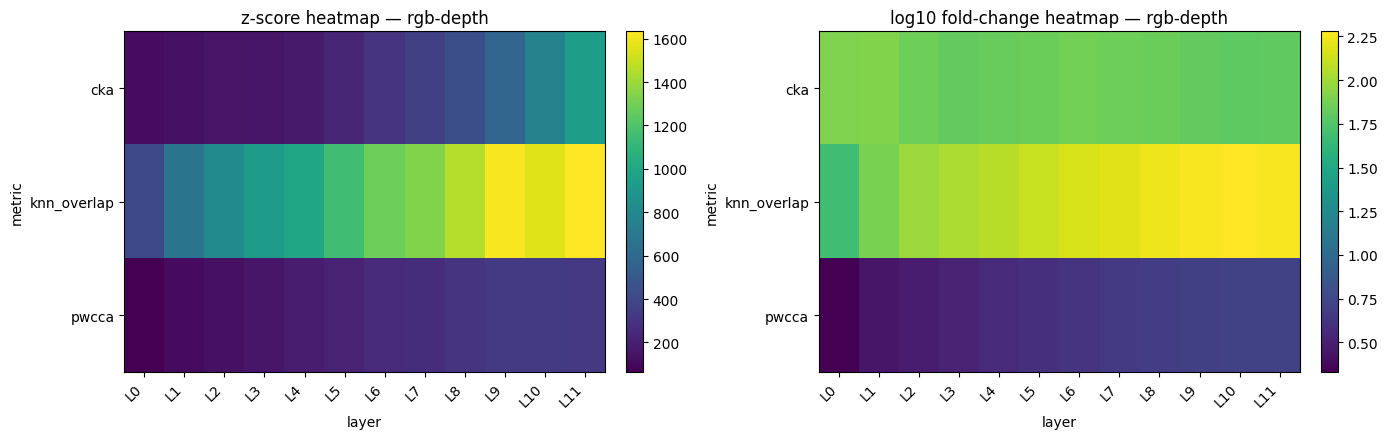

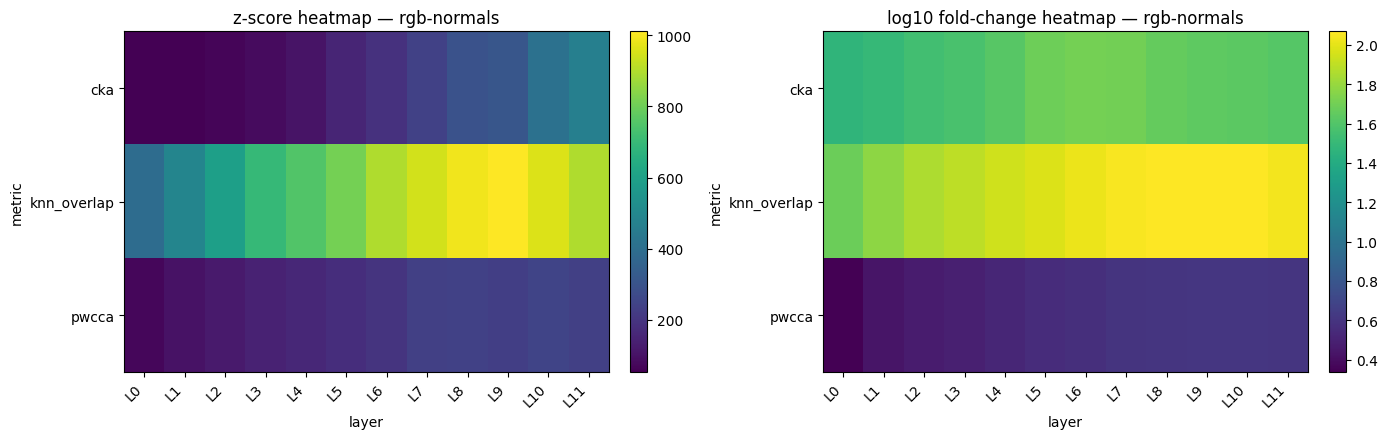

In [13]:
# 3) Heatmaps: z_score and fold-change (log10) for metric x layer.
for pair in sorted(viz_df["pair"].unique()):
    sub_pair = viz_df[viz_df["pair"] == pair].copy()
    if sub_pair.empty:
        continue

    z_mat = (
        sub_pair.pivot_table(index="metric", columns="layer_idx", values="z_score", aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )
    fc_mat = (
        sub_pair.pivot_table(index="metric", columns="layer_idx", values="log10_fold_change", aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    im0 = axes[0].imshow(z_mat.values, aspect="auto", interpolation="nearest")
    axes[0].set_title(f"z-score heatmap — {pair}")
    axes[0].set_xlabel("layer")
    axes[0].set_ylabel("metric")
    axes[0].set_xticks(range(len(z_mat.columns)))
    axes[0].set_xticklabels([f"L{int(c)}" for c in z_mat.columns], rotation=45, ha="right")
    axes[0].set_yticks(range(len(z_mat.index)))
    axes[0].set_yticklabels(z_mat.index.tolist())
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(fc_mat.values, aspect="auto", interpolation="nearest")
    axes[1].set_title(f"log10 fold-change heatmap — {pair}")
    axes[1].set_xlabel("layer")
    axes[1].set_ylabel("metric")
    axes[1].set_xticks(range(len(fc_mat.columns)))
    axes[1].set_xticklabels([f"L{int(c)}" for c in fc_mat.columns], rotation=45, ha="right")
    axes[1].set_yticks(range(len(fc_mat.index)))
    axes[1].set_yticklabels(fc_mat.index.tolist())
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

## Cross-pair comparison

The plots below put the **modality pair** on the same axes so we can read
off how convergence changes between `rgb-depth`, `rgb-normals` and
`depth-normals` directly. Where applicable a Bonferroni (alpha / N) and a
BH-FDR (alpha) threshold are drawn so that significance is comparable
across pairs.


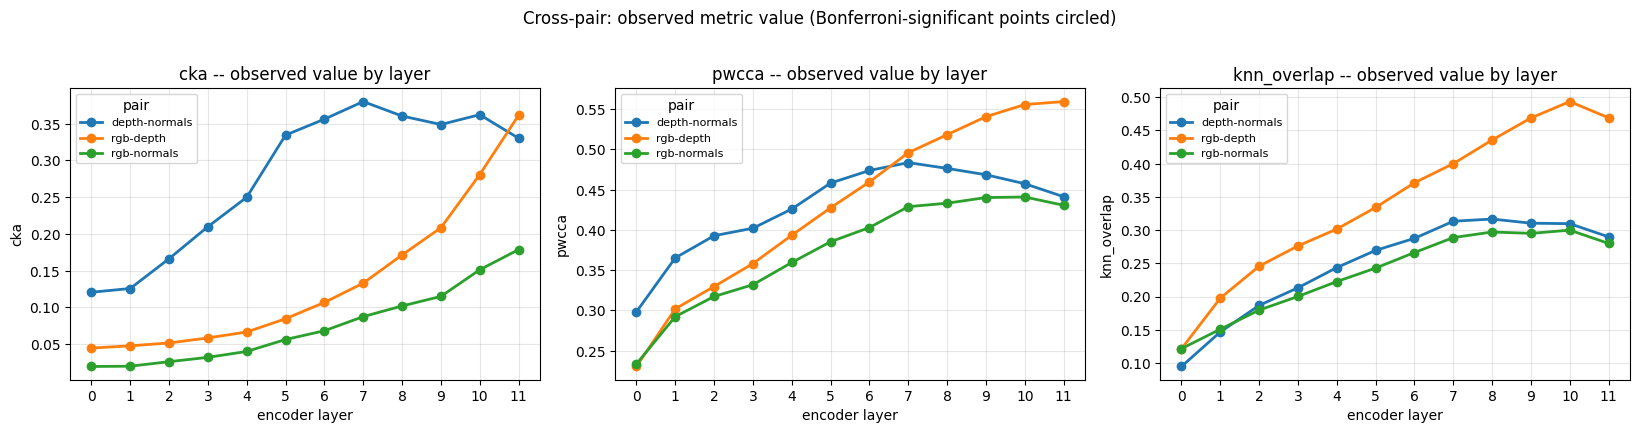

In [14]:
# 1) Observed metric value vs layer, with one coloured line per modality pair.
metric_order = ["cka", "pwcca", "knn_overlap"]
present_metrics = [m for m in metric_order if m in viz_df["metric"].unique()]
pairs_order = sorted(viz_df["pair"].unique())

fig, axes = plt.subplots(1, len(present_metrics), figsize=(5.5 * len(present_metrics), 4.2), sharex=True)
if len(present_metrics) == 1:
    axes = [axes]

for ax, m in zip(axes, present_metrics):
    sub_metric = viz_df[viz_df["metric"] == m]
    for pair in pairs_order:
        sub = sub_metric[sub_metric["pair"] == pair].sort_values("layer_idx")
        if sub.empty:
            continue
        line, = ax.plot(sub["layer_idx"], sub["value"], marker="o", linewidth=2, label=pair)
        # Highlight Bonferroni-significant points with a black ring.
        if "is_significant_bonferroni" in sub.columns:
            sig = sub[sub["is_significant_bonferroni"].fillna(False)]
            if not sig.empty:
                ax.scatter(
                    sig["layer_idx"],
                    sig["value"],
                    s=110,
                    facecolors="none",
                    edgecolors=line.get_color(),
                    linewidths=1.8,
                )
    ax.set_title(f"{m} -- observed value by layer")
    ax.set_xlabel("encoder layer")
    ax.set_ylabel(m)
    ax.set_xticks(sorted(viz_df["layer_idx"].unique()))
    ax.grid(True, alpha=0.3)
    ax.legend(title="pair", loc="best", fontsize=8)

fig.suptitle("Cross-pair: observed metric value (Bonferroni-significant points circled)", y=1.02)
fig.tight_layout()
plt.show()


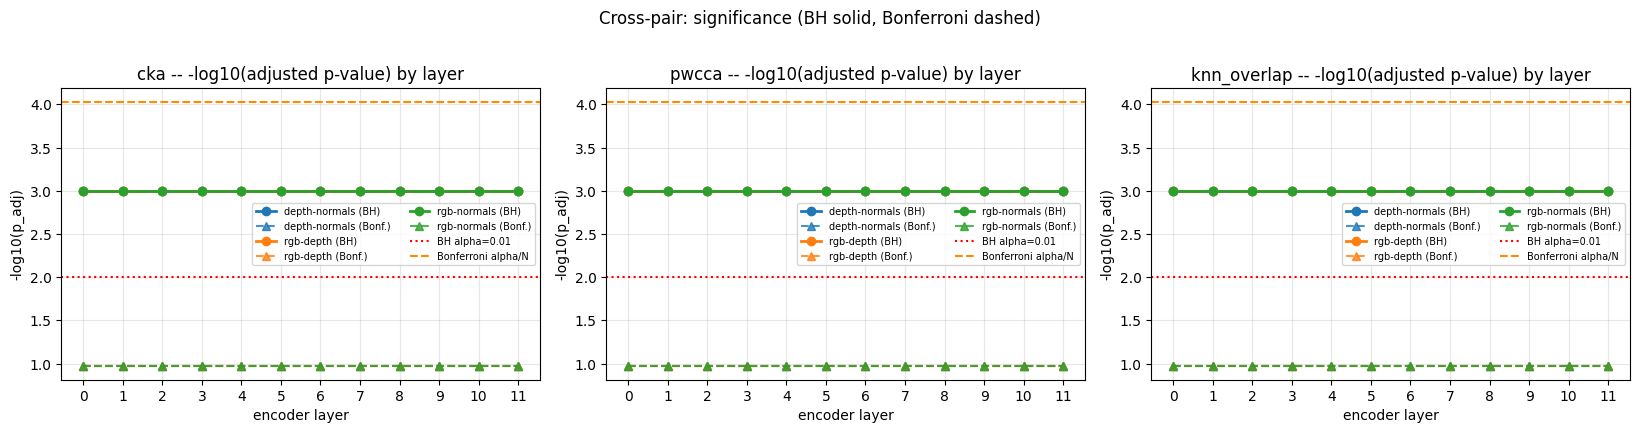

In [15]:
# 2) -log10 adjusted p-values vs layer, paires superposees, par metrique.
fig, axes = plt.subplots(1, len(present_metrics), figsize=(5.5 * len(present_metrics), 4.2), sharex=True)
if len(present_metrics) == 1:
    axes = [axes]

y_alpha_bh = -np.log10(ALPHA)
y_alpha_bonf = -np.log10(ALPHA_BONFERRONI)

for ax, m in zip(axes, present_metrics):
    sub_metric = viz_df[viz_df["metric"] == m].copy()
    if sub_metric.empty or sub_metric["p_value_adjusted"].notna().sum() == 0:
        ax.set_title(f"{m} (no p-values)")
        ax.axis("off")
        continue

    for pair in pairs_order:
        sub = sub_metric[sub_metric["pair"] == pair].sort_values("layer_idx")
        if sub.empty:
            continue
        line, = ax.plot(
            sub["layer_idx"],
            sub["neglog10_p_adj"],
            marker="o",
            linewidth=2,
            label=f"{pair} (BH)",
        )
        ax.plot(
            sub["layer_idx"],
            sub["neglog10_p_bonf"],
            marker="^",
            linestyle="--",
            color=line.get_color(),
            alpha=0.8,
            label=f"{pair} (Bonf.)",
        )

    ax.axhline(y_alpha_bh, linestyle=":", color="red", label=f"BH alpha={ALPHA}")
    ax.axhline(y_alpha_bonf, linestyle="--", color="darkorange", label="Bonferroni alpha/N")
    ax.set_title(f"{m} -- -log10(adjusted p-value) by layer")
    ax.set_xlabel("encoder layer")
    ax.set_ylabel("-log10(p_adj)")
    ax.set_xticks(sorted(viz_df["layer_idx"].unique()))
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=7, ncol=2)

fig.suptitle("Cross-pair: significance (BH solid, Bonferroni dashed)", y=1.02)
fig.tight_layout()
plt.show()


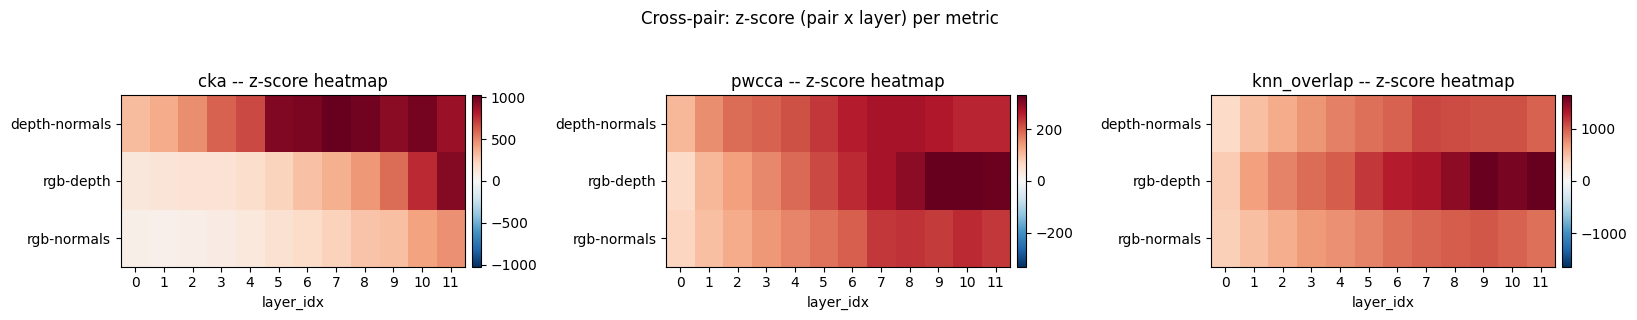

In [16]:
# 3) Heatmaps pair x layer, one per metric (z-score scale).
fig, axes = plt.subplots(1, len(present_metrics), figsize=(5.5 * len(present_metrics), 3.0))
if len(present_metrics) == 1:
    axes = [axes]

for ax, m in zip(axes, present_metrics):
    sub = viz_df[viz_df["metric"] == m]
    if sub.empty or sub["z_score"].notna().sum() == 0:
        ax.set_title(f"{m} (no z-score)")
        ax.axis("off")
        continue

    z_mat = (
        sub.pivot_table(index="pair", columns="layer_idx", values="z_score", aggfunc="mean")
        .reindex(pairs_order)
        .sort_index(axis=1)
    )

    vmax = float(np.nanmax(np.abs(z_mat.values))) if z_mat.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    im = ax.imshow(z_mat.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{m} -- z-score heatmap")
    ax.set_yticks(range(len(z_mat.index)))
    ax.set_yticklabels(z_mat.index)
    ax.set_xticks(range(len(z_mat.columns)))
    ax.set_xticklabels(z_mat.columns)
    ax.set_xlabel("layer_idx")
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

fig.suptitle("Cross-pair: z-score (pair x layer) per metric", y=1.05)
fig.tight_layout()
plt.show()


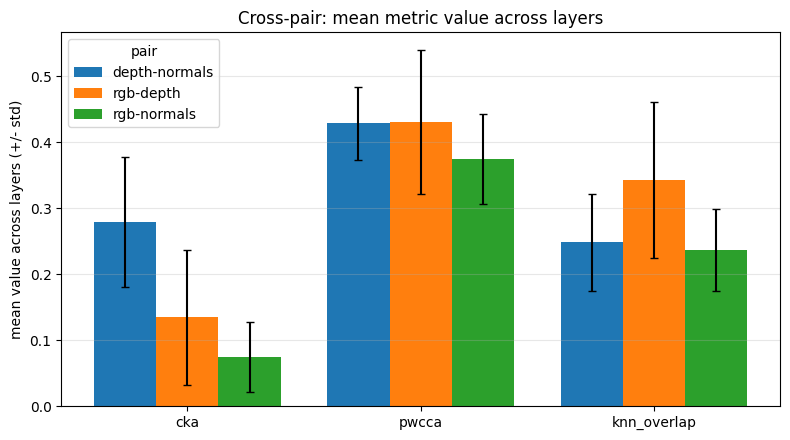

In [17]:
# 4) Bar chart: mean metric value per pair (with std across layers).
agg = (
    viz_df.groupby(["metric", "pair"])["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(present_metrics))
width = 0.8 / max(len(pairs_order), 1)

for i, pair in enumerate(pairs_order):
    means = []
    stds = []
    for m in present_metrics:
        row = agg[(agg["metric"] == m) & (agg["pair"] == pair)]
        means.append(float(row["mean"].iloc[0]) if not row.empty else np.nan)
        stds.append(float(row["std"].iloc[0]) if not row.empty else 0.0)
    offset = (i - (len(pairs_order) - 1) / 2) * width
    ax.bar(x + offset, means, width=width, yerr=stds, capsize=3, label=pair)

ax.set_xticks(x)
ax.set_xticklabels(present_metrics)
ax.set_ylabel("mean value across layers (+/- std)")
ax.set_title("Cross-pair: mean metric value across layers")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="pair")
fig.tight_layout()
plt.show()


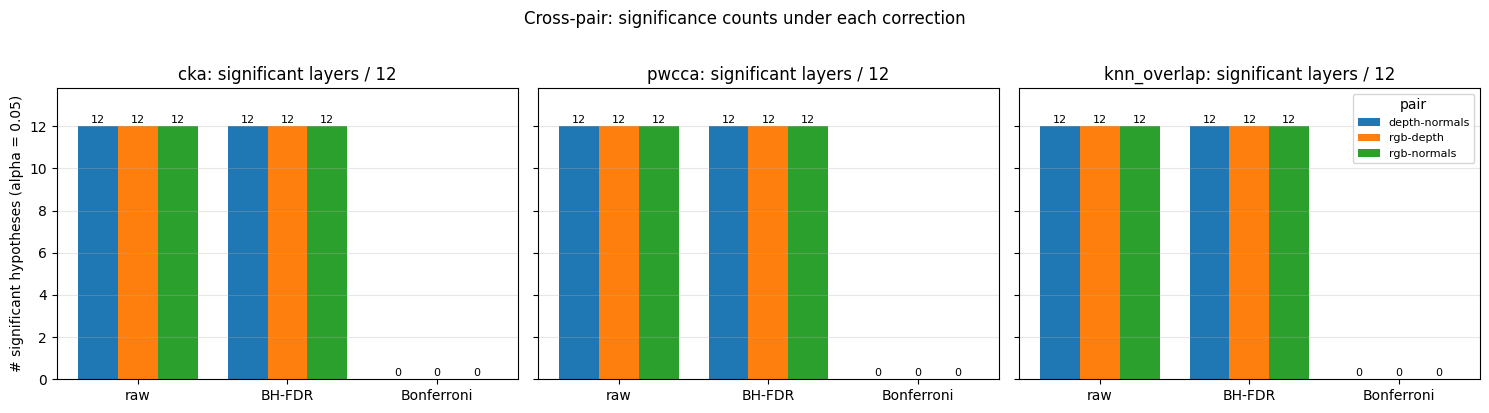

In [18]:
# 5) Bar chart: number of significant hypotheses per pair / metric / correction.
sig_long = (
    sig_counts.reset_index()
    .melt(
        id_vars=["pair", "metric", "n_total"],
        value_vars=["n_sig_raw", "n_sig_bh_fdr", "n_sig_bonferroni"],
        var_name="correction",
        value_name="n_significant",
    )
)
correction_label = {
    "n_sig_raw": "raw",
    "n_sig_bh_fdr": "BH-FDR",
    "n_sig_bonferroni": "Bonferroni",
}
sig_long["correction"] = sig_long["correction"].map(correction_label)

corrections_order = ["raw", "BH-FDR", "Bonferroni"]
n_layers_total = int(viz_df.groupby(["pair", "metric"])["layer"].nunique().max() or 0)

fig, axes = plt.subplots(1, len(present_metrics), figsize=(5.0 * len(present_metrics), 4.0), sharey=True)
if len(present_metrics) == 1:
    axes = [axes]

for ax, m in zip(axes, present_metrics):
    sub = sig_long[sig_long["metric"] == m]
    x = np.arange(len(corrections_order))
    width = 0.8 / max(len(pairs_order), 1)
    for i, pair in enumerate(pairs_order):
        ys = []
        for corr in corrections_order:
            row = sub[(sub["pair"] == pair) & (sub["correction"] == corr)]
            ys.append(int(row["n_significant"].iloc[0]) if not row.empty else 0)
        offset = (i - (len(pairs_order) - 1) / 2) * width
        bars = ax.bar(x + offset, ys, width=width, label=pair)
        for bar, val in zip(bars, ys):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                str(val),
                ha="center",
                va="bottom",
                fontsize=8,
            )
    ax.set_xticks(x)
    ax.set_xticklabels(corrections_order)
    ax.set_ylim(0, max(n_layers_total, 1) * 1.15)
    ax.set_title(f"{m}: significant layers / {n_layers_total}")
    ax.grid(True, axis="y", alpha=0.3)

axes[0].set_ylabel("# significant hypotheses (alpha = 0.05)")
axes[-1].legend(title="pair", loc="best", fontsize=8)
fig.suptitle("Cross-pair: significance counts under each correction", y=1.02)
fig.tight_layout()
plt.show()


In [19]:
# 4) Small report-ready table + CSV export.
report_cols = [
    "pair",
    "metric",
    "layer",
    "n_samples",
    "value",
    "null_mean",
    "null_std",
    "delta_vs_null",
    "z_score",
    "p_value",
    "p_value_adjusted",
    "p_value_bonferroni",
    "alpha_bonferroni_threshold",
    "is_significant",
    "is_significant_bh_fdr",
    "is_significant_bonferroni",
    "log10_fold_change",
]

available_cols = [c for c in report_cols if c in viz_df.columns]
report_ready = (
    viz_df.sort_values(["pair", "metric", "layer_idx"])
    .loc[:, available_cols]
    .reset_index(drop=True)
)

out_root = project_root / "results" / "runs" / RUN_ID / "diagnostics"
out_root.mkdir(parents=True, exist_ok=True)
out_csv = out_root / "report_ready_significance_table.csv"
report_ready.to_csv(out_csv, index=False)

print(f"Saved report-ready table: {out_csv}")
display(report_ready)


Saved report-ready table: C:\Users\arthu\Desktop\EPFL\MA2\Visual Intelligence\one-trunk-or-many\results\runs\rq1_final_hypersim-20260525-000411\diagnostics\report_ready_significance_table.csv


,pair,metric,layer,n_samples,value,null_mean,null_std,delta_vs_null,z_score,p_value,p_value_adjusted,p_value_bonferroni,alpha_bonferroni_threshold,is_significant,is_significant_bh_fdr,is_significant_bonferroni,log10_fold_change
0,depth-normals,cka,layer_00,4000,0.120624,0.000982,0.000371,0.119641,322.588189,0.000999,0.000999,0.107892,0.000093,True,True,False,2.089230
1,depth-normals,cka,layer_01,4000,0.125713,0.001008,0.000330,0.124705,377.985631,0.000999,0.000999,0.107892,0.000093,True,True,False,2.095783
2,depth-normals,cka,layer_02,4000,0.166277,0.001307,0.000345,0.164969,478.492048,0.000999,0.000999,0.107892,0.000093,True,True,False,2.104509
3,depth-normals,cka,layer_03,4000,0.209872,0.001597,0.000344,0.208275,606.316636,0.000999,0.000999,0.107892,0.000093,True,True,False,2.118641
4,depth-normals,cka,layer_04,4000,0.249891,0.001825,0.000369,0.248066,672.732762,0.000999,0.000999,0.107892,0.000093,True,True,False,2.136481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,rgb-normals,pwcca,layer_07,4000,0.428839,0.107506,0.001371,0.321333,234.307145,0.000999,0.000999,0.107892,0.000093,True,True,False,0.600862
104,rgb-normals,pwcca,layer_08,4000,0.433143,0.107486,0.001359,0.325656,239.630127,0.000999,0.000999,0.107892,0.000093,True,True,False,0.605278
105,rgb-normals,pwcca,layer_09,4000,0.440161,0.107544,0.001438,0.332617,231.256791,0.000999,0.000999,0.107892,0.000093,True,True,False,0.612026
106,rgb-normals,pwcca,layer_10,4000,0.440848,0.107585,0.001338,0.333263,249.026573,0.000999,0.000999,0.107892,0.000093,True,True,False,0.612538
